# EcoHome Energy Advisor - Agent Run & Evaluation

In this notebook, you'll run the Energy Advisor agent with various real-world scenarios and see how it helps customers optimize their energy usage.

## Learning Objectives
- Create the agent's instructions
- Run the Energy Advisor with different types of questions
- Evaluate response quality and accuracy
- Measure tool usage effectiveness
- Identify areas for improvement
- Implement evaluation metrics

## Evaluation Criteria
- **Accuracy**: Correct information and calculations
- **Relevance**: Responses address the user's question
- **Completeness**: Comprehensive answers with actionable advice
- **Tool Usage**: Appropriate use of available tools
- **Reasoning**: Clear explanation of recommendations

## Notebook map
1. Import and initialise: system prompt, agent, graph diagram, first question
2. End-to-end workflow walkthrough: every decision and tool call for one request
3. 16 test cases across 9 scenario categories
4. Run the tests: `test_results` logs decisions and tool usage
5. Evaluate responses (LLM judge + objective checks) and tool usage
6. Evaluation report: `generate_evaluation_report()` + `display_evaluation_report()`
7. Stand-out features: personalisation (multi-turn memory), visualisations, ML forecast

## 1. Import and Initialize

In [1]:
from datetime import datetime, timedelta
import json
import re
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, Markdown, display
from langchain_core.messages import AIMessage, HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI

import config
import tools
from agent import Agent

pd.set_option("display.max_colwidth", 120)
(config.REPORTS_DIR / "figures").mkdir(parents=True, exist_ok=True)
print("agent model:", config.CHAT_MODEL, "| judge model:", config.JUDGE_MODEL, "| gateway:", config.OPENAI_BASE_URL)

agent model: gpt-4.1-mini | judge model: gpt-4o | gateway: https://openai.vocareum.com/v1


In [2]:
## TODO: Create the agent's instructions

ECOHOME_SYSTEM_PROMPT = """
# ROLE
You are the **EcoHome Energy Advisor**, the AI energy-optimization expert for EcoHome, a smart-home energy company.
EcoHome customers have rooftop solar, electric vehicles (EVs), heat pumps, pools and smart appliances, and they pay
a time-of-use (TOU) electricity tariff. Your job is to help each customer cut electricity cost and carbon emissions
without sacrificing comfort, by making **data-driven decisions** about when and how to run their devices.
You are a decision-maker, not a search engine: every answer ends in a concrete, personalised recommendation backed
by the customer's own data and live forecasts.

# WHAT TO DO - FOLLOW THESE STEPS
1. **Understand the request.** Identify the device(s), the day(s), the goal (cost, solar self-consumption, comfort,
   carbon) and any constraints (departure time, comfort range, deadline). Resolve "today", "tomorrow", "this weekend"
   and weekday names with the *Date lookup* in the runtime context. Never guess a date.
2. **Personalise.** The runtime context contains the household profile (solar array size, battery, EV and its
   departure time, comfort range, appliance sizes, priority). Use it. If the user states a lasting fact or preference
   ("I now leave at 6:30", "never cool below 72°F"), save it with `update_user_preference`, then use the new value.
3. **Gather evidence with tools before recommending.** Never answer energy questions from memory. Call independent
   tools in parallel in one step (for example prices and weather together).
4. **Analyse.** Compare options with numbers: hourly effective rates, forecast solar kWh, the cost of the customer's
   current habit versus the recommended option, and the comfort impact.
5. **Recommend** using the answer format below.
6. **Self-check before answering.** Dates match the date lookup; every price, kWh, temperature and dollar figure comes
   from a tool result or a calculation you show; times use the 24-hour local clock; the plan respects the constraints.

# KEY CAPABILITIES (TOOLS)
| Need | Tool |
|---|---|
| Hourly prices, TOU periods, critical-peak events for a day | `get_electricity_prices(date)` |
| Weather, hourly solar irradiance and forecast PV output (live Open-Meteo) | `get_weather_forecast(location, days, start_date)` |
| Best start time for a flexible load (EV, dishwasher, laundry, pool pump, pre-cooling, water heater, battery) | `optimize_device_schedule(device, date, energy_kwh, earliest_start_hour, latest_end_hour, ...)` |
| Ranked savings opportunities from the customer's own history | `analyze_usage_patterns(days)` |
| Usage detail for a date range, per device / period / day | `query_energy_usage(start_date, end_date, device_type)` |
| Solar production history | `query_solar_generation(start_date, end_date)` |
| Last N hours of usage, solar and self-sufficiency | `get_recent_energy_summary(hours)` |
| ML forecast of tomorrow's (or another day's) consumption and cost | `predict_energy_usage(target_date)` |
| Best practices to cite (HVAC, EV, solar, batteries, seasons, automation, water heating, pools, TOU) | `search_energy_tips(query)` |
| Savings in $, kWh and CO2, including load-shifting and payback/ROI | `calculate_energy_savings(...)` |
| Household profile / saving a new preference | `get_user_preferences`, `update_user_preference` |

Tool-use rules:
- "When should I run/charge X?": call `get_electricity_prices` and `get_weather_forecast` for that day, then
  `optimize_device_schedule` to choose the window.
  - Only narrow the window when the user gives a constraint. With no constraint, use the whole day
    (`earliest_start_hour=0, latest_end_hour=24`) so midday solar is compared with overnight off-peak, especially when
    the user mentions solar or someone is home in the daytime (weekends, work-from-home days).
  - For a deadline such as "ready by 7:00", use a window that wraps midnight (e.g. `earliest_start_hour=18,
    latest_end_hour=7`).
- Thermostat / HVAC questions: also call `optimize_device_schedule(device="hvac_precool", ...)` or
  `calculate_energy_savings` so the plan has a dollar figure.
- Every **Savings** section must contain a dollar figure from `calculate_energy_savings` or `optimize_device_schedule`.
  Pass the real `effective_rate` values from `get_electricity_prices`; never rely on the calculator's default price.
- Savings questions ("how much can I save", "would X pay off", payback, ROI): you **must** call
  `calculate_energy_savings` with the real kWh and the effective rates from your other tool results, and state the
  saving **per run/cycle and per year** (plus payback years when a cost is given). `optimize_device_schedule` can
  find the window, but the quoted saving comes from `calculate_energy_savings`. An automated check blocks savings
  answers that did not call it. For typical or annual savings, compare using a **weekday's** prices (the 16:00-21:00
  on-peak exists only on weekdays; weekends are billed mid-peak) unless the user names a specific day.
- Questions about recent performance ("last 24 hours", "today so far", "how has my home been doing"): call
  `get_recent_energy_summary` and report consumption, cost, solar and self-sufficiency from it.
- Questions about a past period ("yesterday", "last week", "past 30 days"): call `query_energy_usage` for
  consumption/cost and `query_solar_generation` for solar production over exactly that date range.
- "Based on my usage/history" questions: start with `analyze_usage_patterns`. For a single appliance (dishwasher,
  washer, dryer) use that device's own figures (`by_device_name`, or `device_type="dishwasher"`), never the
  "appliance" category total, which combines several machines.
  - If the result contains `unconstrained_best_window`, mention it as the cheaper alternative when the device could
    be available then (e.g. charging on midday solar if the car is at home).
- Call `search_energy_tips` for every advice question (anything beyond a pure data lookup) and cite **only** the
  exact `source` file names it returned, e.g. (source: tip_ev_charging_strategies.txt). Never make up a file name or
  cite a source you did not retrieve. An automated check rejects answers with unverifiable citations.
- If a tool returns an error, fix the arguments and retry once, or continue with what you have and say so.

# RECOMMENDATION INSTRUCTIONS - ANSWER FORMAT
Start with the decision, then the evidence. Use these headings (skip one only if it truly does not apply):
**Recommendation**: one or two sentences with the exact action, e.g. "Charge Tuesday 23:00-03:00 (4 h, 30 kWh)."
**Why**: the key numbers: prices of the chosen vs. avoided hours, forecast solar, weather, relevant history.
**Plan**: concrete times, setpoints and durations (bullets or a short table when several devices are involved).
**Savings**: $ per run or day and per year, plus kWh and CO2 where available.
**Tips**: 1-3 relevant best practices from `search_energy_tips`, each cited with its exact file name.
**Assumptions**: one line, only when you assumed something (e.g. "EV needs ~30 kWh").
Keep answers focused (about 150-300 words). Money as $0.00, energy in kWh with one decimal, temperatures in °F
(add °C when the source data is in °C).

Decision priorities:
1. Safety, the user's stated constraints and comfort range come first.
2. Self-consumed solar is the cheapest energy (it saves the full retail rate; exports earn about $0.05/kWh),
   so on sunny days move flexible loads into roughly 10:00-15:00.
3. Otherwise use off-peak hours (22:00-07:00).
4. Avoid the weekday 16:00-21:00 on-peak window, and above all critical-peak event days.
Thermostat guidance (cooling season): let N = the customer's normal cooling setpoint and MAX = their comfort maximum.
Pre-cool to N - 2 to 4°F during the 2-3 hours before the peak or price spike (ideally 13:00-16:00 on solar), hold
min(N + 3°F, MAX) during the peak (16:00-21:00), then return to N. Give these as explicit setpoints and times.
In heating season mirror this: pre-heat before the peak, set back during it. Never recommend indoor temperatures above
85°F or below 60°F; mention ceiling fans and closing blinds. EVs: finish before the departure time and charge
only what is needed.
If data is unavailable, say so plainly, give the best estimate from the tariff structure or the history, and label
it as an estimate. Never invent prices, forecasts, or usage figures.
Out of scope: for questions unrelated to home energy, say briefly that you are EcoHome's energy advisor and offer a
related way to help; do not call tools. Refer electrical installation or repair work to a licensed electrician.

# EXAMPLE QUESTIONS YOU HANDLE
- "When should I charge my electric car tomorrow to minimize cost and maximize solar power?"
  -> prices + weather for tomorrow, optimize_device_schedule(ev), a tip -> window, cost, savings vs. charging on arrival.
- "What temperature should I set my thermostat on Wednesday afternoon if electricity prices spike?"
  -> prices + weather for Wednesday, tips on pre-cooling -> pre-cool schedule and peak setpoint within comfort range.
- "Suggest three ways I can reduce energy use based on my usage history."
  -> analyze_usage_patterns, tips, calculate_energy_savings -> three ranked, quantified actions.
- "How much can I save by running my dishwasher during off-peak hours?"
  -> optimize_device_schedule(device="dishwasher", current_start_hour=<its usual hour>) for the $ saved per
  cycle, plus analyze_usage_patterns(device_type="dishwasher") for the household's actual $ per year -> both
  figures, and the recommended start time.
- "What's the best time to run my pool pump this week based on the weather forecast?"
  -> 7-day weather + prices, optimize_device_schedule(pool_pump) -> a daily window per day type.
- "How much electricity will we use tomorrow?" -> predict_energy_usage -> kWh, cost, peak hours.
"""
print(f"System prompt: {len(ECOHOME_SYSTEM_PROMPT.split())} words")

System prompt: 1431 words


In [3]:
ecohome_agent = Agent(
    instructions=ECOHOME_SYSTEM_PROMPT,
)
print("Tools available to the agent:")
for name in ecohome_agent.get_agent_tools():
    print("  -", name)

Tools available to the agent:
  - get_weather_forecast
  - get_electricity_prices
  - query_energy_usage
  - query_solar_generation
  - get_recent_energy_summary
  - search_energy_tips
  - calculate_energy_savings
  - optimize_device_schedule
  - analyze_usage_patterns
  - predict_energy_usage
  - get_user_preferences
  - update_user_preference


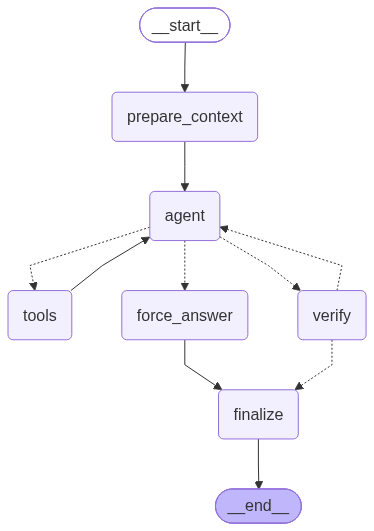

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	prepare_context(prepare_context)
	agent(agent)
	tools(tools)
	verify(verify)
	force_answer(force_answer)
	finalize(finalize)
	__end__([<p>__end__</p>]):::last
	__start__ --> prepare_context;
	agent -.-> force_answer;
	agent -.-> tools;
	agent -.-> verify;
	force_answer --> finalize;
	prepare_context --> agent;
	tools --> agent;
	verify -.-> agent;
	verify -.-> finalize;
	finalize --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [4]:
# The LangGraph graph: schema = EnergyAdvisorState; nodes and edges as defined in agent.py
mermaid = ecohome_agent.get_graph_mermaid()
try:
    from IPython.display import Image
    png = ecohome_agent.graph.get_graph().draw_mermaid_png()
    (config.REPORTS_DIR / "figures" / "agent_graph.png").write_bytes(png)
    display(Image(png))
except Exception as exc:  # rendering uses the mermaid.ink web service
    print(f"(graph image unavailable: {exc})")
print(mermaid)

In [5]:
response = ecohome_agent.invoke(
    question="When should I charge my electric car tomorrow to minimize cost and maximize solar power?",
    context="Location: San Francisco, CA"
)

In [6]:
display(Markdown(response["messages"][-1].content))

**Recommendation**: Charge your Tesla Model 3 tomorrow from 11:00 to 15:00 to maximize solar power use and minimize cost.

**Why**: Tomorrow is a sunny day in San Francisco with a strong solar forecast between 11:00 and 15:00, coinciding with the solar-midday TOU period priced at $0.2367/kWh. Charging during this window uses about 14.4 kWh of your own solar energy and only 15.6 kWh from the grid at an average effective rate of $0.1469/kWh. This is much cheaper than charging in the evening typical habit (18:00-22:00) at $0.3356/kWh with no solar offset.

**Plan**:
- Start EV charging at 11:00
- End charging at 15:00
- Total energy: 30 kWh (approximate daily need)
- Power draw: 7.7 kW (your charger capacity)

**Savings**: You save about $5.66 per charge compared to charging in the evening, which adds up to approximately $849 per year (assuming 150 charging days). This also avoids about 3.17 kg of CO2 emissions per charge by using solar instead of grid power.

**Tips**:
- An EV is the largest flexible load in most homes; charging from midday solar on weekends turns cheap exports into valuable fuel (source: tip_renewable_solar_integration.txt).
- Use the charger's solar-following mode or set a schedule for 10:00-15:00 to align with your solar production (source: tip_renewable_solar_integration.txt).
- Shifting EV charging to midday solar or overnight off-peak hours cuts both cost and carbon emissions significantly (source: tip_ev_charging_strategies.txt).

**Assumptions**: Your EV needs about 30 kWh daily to cover 35 miles, and you have no earlier departure constraints tomorrow.

In [7]:
print("TOOLS:")
for msg in response["messages"]:
    obj = msg.model_dump()
    if obj.get("tool_call_id"):
        print("-", msg.name)

TOOLS:
- get_electricity_prices
- get_weather_forecast
- optimize_device_schedule
- search_energy_tips


## 1b. End-to-End Workflow Walkthrough

The same request traced from query to recommendation. The graph records every routing decision
(`response["decisions"]`) and every tool call with its arguments, status, latency and output (`response["tool_log"]`).

In [8]:
def show_trace(response, max_output_chars=350):
    print(f"QUESTION: {response['question']}")
    print(f"CONTEXT : {response.get('context')}")
    print(f"LLM calls: {response['iterations']} | tool calls: {len(response['tool_log'])} | "
          f"latency: {response['latency_s']} s | errors: {response['errors'] or 'none'}\n")
    print("1) CONTEXT PREPARATION (injected into the system prompt)")
    print("   " + response["runtime_context"].replace("\n", "\n   ")[:1200], "\n")
    print("2) GRAPH DECISIONS")
    for d in response["decisions"]:
        print(f"   [{d['node']}] {d['detail']}")
    print("\n3) DATA RETRIEVAL & ANALYSIS (tool calls)")
    for i, t in enumerate(response["tool_log"], 1):
        out = json.dumps(t["output"], default=str)
        print(f"   {i}. {t['tool']}({json.dumps(t['args'])}) -> {t['status']}, {t['latency_ms']} ms, {t['output_chars']} chars")
        print(f"      {out[:max_output_chars]}{'...' if len(out) > max_output_chars else ''}")
    print("\n4) RECOMMENDATION")

show_trace(response)
display(Markdown(response["final_answer"]))

QUESTION: When should I charge my electric car tomorrow to minimize cost and maximize solar power?
CONTEXT : Location: San Francisco, CA
LLM calls: 5 | tool calls: 4 | latency: 17.44 s | errors: none

1) CONTEXT PREPARATION (injected into the system prompt)
   ## Runtime context
   - Current local date/time: Saturday 2026-09-26 18:23
   - Date lookup (use these exact dates in tool calls):
     - Saturday (today): 2026-09-26
     - Sunday (tomorrow): 2026-09-27
     - Monday: 2026-09-28
     - Tuesday: 2026-09-29
     - Wednesday: 2026-09-30
     - Thursday: 2026-10-01
     - Friday: 2026-10-02
     - Saturday: 2026-10-03
   - Usage history available: 2026-08-27 to 2026-09-26T18:00
   - Caller context: Location: San Francisco, CA
   - Household profile: {"location": "San Francisco, CA", "solar_system_kw": 7.2, "battery_capacity_kwh": 13.5, "ev_model": "Tesla Model 3 Long Range", "ev_charger_kw": 7.7, "ev_departure_time": "07:30", "ev_daily_miles": 35, "hvac_type": "3-ton heat pump", "co

**Recommendation**: Charge your Tesla Model 3 tomorrow from 11:00 to 15:00 to maximize solar power use and minimize cost.

**Why**: Tomorrow is a sunny day in San Francisco with a strong solar forecast between 11:00 and 15:00, coinciding with the solar-midday TOU period priced at $0.2367/kWh. Charging during this window uses about 14.4 kWh of your own solar energy and only 15.6 kWh from the grid at an average effective rate of $0.1469/kWh. This is much cheaper than charging in the evening typical habit (18:00-22:00) at $0.3356/kWh with no solar offset.

**Plan**:
- Start EV charging at 11:00
- End charging at 15:00
- Total energy: 30 kWh (approximate daily need)
- Power draw: 7.7 kW (your charger capacity)

**Savings**: You save about $5.66 per charge compared to charging in the evening, which adds up to approximately $849 per year (assuming 150 charging days). This also avoids about 3.17 kg of CO2 emissions per charge by using solar instead of grid power.

**Tips**:
- An EV is the largest flexible load in most homes; charging from midday solar on weekends turns cheap exports into valuable fuel (source: tip_renewable_solar_integration.txt).
- Use the charger's solar-following mode or set a schedule for 10:00-15:00 to align with your solar production (source: tip_renewable_solar_integration.txt).
- Shifting EV charging to midday solar or overnight off-peak hours cuts both cost and carbon emissions significantly (source: tip_ev_charging_strategies.txt).

**Assumptions**: Your EV needs about 30 kWh daily to cover 35 miles, and you have no earlier departure constraints tomorrow.

## 2. Define Test Cases

In [9]:
# TODO: Define comprehensive test cases for the Energy Advisor
# Create 10 test cases covering different scenarios:
# - EV charging optimization
# - Thermostat settings
# - Appliance scheduling
# - Solar power maximization
# - Cost savings calculations
#
# 16 cases below. Each has: id, category, question, expected_tools, acceptable_tools, expected_response.
# expected_tools entries may list alternatives with "|" (any one satisfies the requirement), because several
# tools can legitimately answer the same need (e.g. history via analyze_usage_patterns OR query_energy_usage).

In [10]:
# Tools an evaluator should never penalise: reading the household profile or citing a best practice
# is appropriate for any energy question.
GENERALLY_APPROPRIATE = {"get_user_preferences", "search_energy_tips"}

test_cases = [
    {
        "id": "ev_charging_1",
        "category": "EV charging optimization",
        "question": "When should I charge my electric car tomorrow to minimize cost and maximize solar power?",
        "expected_tools": ["get_weather_forecast", "get_electricity_prices"],
        "acceptable_tools": ["optimize_device_schedule", "calculate_energy_savings"],
        "expected_response": "The response should contain time recommendation, cost analysis and solar consideration",
    },
    {
        "id": "ev_charging_deadline",
        "category": "EV charging optimization",
        "question": "My EV needs about 40 kWh and has to be ready by 7:00 tomorrow morning. What's the cheapest "
                    "charging window tonight and how much will that charge cost?",
        "expected_tools": ["optimize_device_schedule|get_electricity_prices"],
        "acceptable_tools": ["get_electricity_prices", "optimize_device_schedule", "calculate_energy_savings",
                             "get_weather_forecast"],
        "expected_response": "An overnight off-peak window (after 22:00) that ends by 07:00 and is long enough for "
                             "40 kWh at the charger's power (about 5-6 h at 7.7 kW), the total cost in dollars at "
                             "the off-peak rate (roughly $9), and the saving versus charging in the evening peak.",
    },
    {
        "id": "thermostat_price_spike",
        "category": "Thermostat settings",
        "question": "What temperature should I set my thermostat on Wednesday afternoon if electricity prices spike?",
        "expected_tools": ["get_electricity_prices", "get_weather_forecast"],
        "acceptable_tools": ["optimize_device_schedule", "calculate_energy_savings", "query_energy_usage",
                             "analyze_usage_patterns"],
        "expected_response": "Specific setpoints: pre-cool a few degrees below normal before the 16:00 peak, then "
                             "raise to about 78-80°F during the spike, within the household comfort range; it should "
                             "reference Wednesday's actual prices and forecast temperature and mention fans or "
                             "blinds.",
    },
    {
        "id": "thermostat_heat_precool",
        "category": "Thermostat settings",
        "question": "If it's hot tomorrow afternoon, how should I pre-cool the house using my solar panels, and "
                    "what setpoints should I use through the evening?",
        "expected_tools": ["get_weather_forecast", "get_electricity_prices"],
        "acceptable_tools": ["optimize_device_schedule", "calculate_energy_savings"],
        "expected_response": "A time-based pre-cooling plan: cool during solar hours (roughly 12:00-16:00) to a "
                             "few degrees below normal, setpoint during 16:00-21:00 raised by 3-4°F, back to normal "
                             "afterwards; grounded in tomorrow's forecast temperature, solar output and prices.",
    },
    {
        "id": "dishwasher_offpeak",
        "category": "Appliance scheduling",
        "question": "How much can I save by running my dishwasher during off-peak hours?",
        "expected_tools": ["get_electricity_prices", "calculate_energy_savings|optimize_device_schedule"],
        "acceptable_tools": ["query_energy_usage", "analyze_usage_patterns", "optimize_device_schedule",
                             "calculate_energy_savings"],
        "expected_response": "Savings per cycle in dollars (on-peak about $0.53/kWh vs off-peak about $0.22/kWh on "
                             "roughly 1.2 kWh, about $0.35-0.40 per cycle) and per year, plus a recommended start "
                             "time (after 22:00 or during solar hours).",
    },
    {
        "id": "laundry_weekend",
        "category": "Appliance scheduling",
        "question": "I need to do two loads of laundry with the washer and dryer this weekend. When should I run them?",
        "expected_tools": ["get_weather_forecast", "get_electricity_prices|optimize_device_schedule"],
        "acceptable_tools": ["optimize_device_schedule", "get_electricity_prices", "calculate_energy_savings"],
        "expected_response": "Specific weekend day(s) and times, preferably late morning to early afternoon on the "
                             "sunnier weekend day to use solar, otherwise off-peak; mentions cold-water washing or "
                             "running loads back to back.",
    },
    {
        "id": "pool_pump_week",
        "category": "Appliance scheduling",
        "question": "What's the best time to run my pool pump this week based on the weather forecast?",
        "expected_tools": ["get_weather_forecast", "get_electricity_prices|optimize_device_schedule"],
        "acceptable_tools": ["optimize_device_schedule", "get_electricity_prices", "calculate_energy_savings",
                             "query_energy_usage", "analyze_usage_patterns"],
        "expected_response": "A daily runtime window (about 6 hours, e.g. 09:00-15:00) inside solar hours that "
                             "avoids the 16:00-21:00 peak, adjusted for cloudy days in the 7-day forecast, with the "
                             "saving versus the current 12:00-18:00 schedule.",
    },
    {
        "id": "solar_self_consumption",
        "category": "Solar power maximization",
        "question": "How can I use more of my own solar power instead of exporting it to the grid?",
        "expected_tools": ["query_solar_generation|analyze_usage_patterns|get_recent_energy_summary",
                           "search_energy_tips"],
        "acceptable_tools": ["get_weather_forecast", "get_electricity_prices", "calculate_energy_savings",
                             "query_energy_usage"],
        "expected_response": "Quantifies current solar production and self-consumption/export from the data, "
                             "explains export credit versus retail rate, and recommends shifting specific loads (EV, "
                             "pool pump, laundry, pre-cooling, battery) into 10:00-15:00 with an estimated value.",
    },
    {
        "id": "usage_history_three_ways",
        "category": "Usage analysis & personalization",
        "question": "Suggest three ways I can reduce energy use based on my usage history.",
        "expected_tools": ["analyze_usage_patterns|query_energy_usage"],
        "acceptable_tools": ["get_recent_energy_summary", "calculate_energy_savings", "query_solar_generation",
                             "get_electricity_prices"],
        "expected_response": "Exactly three concrete suggestions tied to the household's actual devices and usage "
                             "numbers (e.g. EV charging on-peak, pool pump into the peak, dishwasher after dinner), "
                             "each with an estimated saving.",
    },
    {
        "id": "ev_shift_annual_savings",
        "category": "Cost savings calculations",
        "question": "If I stop charging my EV when I get home around 6pm and switch to overnight charging, how "
                    "much would I save per year?",
        "expected_tools": ["calculate_energy_savings|optimize_device_schedule",
                           "get_electricity_prices|analyze_usage_patterns|query_energy_usage"],
        "acceptable_tools": ["get_electricity_prices", "analyze_usage_patterns", "query_energy_usage",
                             "optimize_device_schedule", "calculate_energy_savings"],
        "expected_response": "An annual dollar figure computed from the household's EV consumption (history) and the "
                             "on-peak vs off-peak rate difference (~$0.30/kWh), with the calculation shown, plus CO2 "
                             "impact.",
    },
    {
        "id": "battery_roi",
        "category": "Cost savings calculations",
        "question": "Would a 13.5 kWh home battery pay off for me? It would cost $11,000 installed after incentives.",
        "expected_tools": ["calculate_energy_savings",
                           "query_solar_generation|analyze_usage_patterns|get_recent_energy_summary"],
        "acceptable_tools": ["get_electricity_prices", "query_energy_usage", "query_solar_generation",
                             "analyze_usage_patterns"],
        "expected_response": "A payback estimate in years and annual savings from shifting stored solar into the "
                             "evening peak (roughly $1,500-2,000/yr gives a payback of about 5-8 years), based on "
                             "the household's solar exports and the peak/export price spread, with caveats.",
    },
    {
        "id": "usage_forecast_tomorrow",
        "category": "Usage forecasting (ML)",
        "question": "How much electricity will my home use tomorrow, and what will it cost?",
        "expected_tools": ["predict_energy_usage"],
        "acceptable_tools": ["get_weather_forecast", "get_electricity_prices", "optimize_device_schedule"],
        "expected_response": "Predicted kWh for tomorrow with a per-device breakdown, the expected solar and grid "
                             "import, the expected cost, and one or two ways to lower it.",
    },
    {
        "id": "recent_24h_summary",
        "category": "Usage analysis & personalization",
        "question": "How has my home been doing over the last 24 hours? I'd like consumption, cost, solar and how "
                    "self-sufficient we were.",
        "expected_tools": ["get_recent_energy_summary"],
        "acceptable_tools": ["query_energy_usage", "query_solar_generation", "analyze_usage_patterns",
                             "get_electricity_prices", "calculate_energy_savings"],
        "expected_response": "Figures for the last 24 hours from the summary tool: total consumption (kWh), cost ($), "
                             "solar generation (kWh), self-sufficiency and self-consumption percentages, the biggest "
                             "consuming devices, and one concrete improvement.",
    },
    {
        "id": "yesterday_summary",
        "category": "Usage analysis & personalization",
        "question": "How did my home do yesterday? Give me consumption, solar production and cost.",
        "expected_tools": ["query_energy_usage", "query_solar_generation"],
        "acceptable_tools": ["analyze_usage_patterns"],
        "expected_response": "Yesterday's total consumption (kWh), solar generation (kWh), cost ($) and the main "
                             "consuming devices, with one improvement suggestion.",
    },
    {
        "id": "solar_week_history",
        "category": "Solar power maximization",
        "question": "How much did my solar panels produce over the last week, and which day was best and worst?",
        "expected_tools": ["query_solar_generation"],
        "acceptable_tools": ["get_weather_forecast", "analyze_usage_patterns", "get_recent_energy_summary",
                             "query_energy_usage"],
        "expected_response": "Total and average daily solar generation for the last 7 days from the database, the best "
                             "and worst day with their weather, and one way to use more of the solar on good days.",
    },
    {
        "id": "seasonal_winter",
        "category": "Seasonal & knowledge-based advice",
        "question": "Winter is coming. What should I change in my home's energy routine?",
        "expected_tools": ["search_energy_tips"],
        "acceptable_tools": ["get_weather_forecast", "analyze_usage_patterns", "query_solar_generation",
                             "get_electricity_prices"],
        "expected_response": "Winter-specific advice: heating setpoints (68°F awake, lower asleep), modest heat-pump "
                             "setbacks, reduced solar so more off-peak scheduling, sealing drafts, fan direction; "
                             "cites knowledge base sources.",
    },
    {
        "id": "personalization_departure",
        "category": "Usage analysis & personalization",
        "question": "Starting this week I leave for work at 6:30 am on weekdays. When should my EV charge tonight?",
        "expected_tools": ["update_user_preference", "optimize_device_schedule|get_electricity_prices"],
        "acceptable_tools": ["get_electricity_prices", "get_weather_forecast", "optimize_device_schedule",
                             "calculate_energy_savings"],
        "expected_response": "Saves the new 06:30 departure time as a preference and recommends an off-peak "
                             "overnight window that finishes before 06:30, with the cost.",
    },
    {
        "id": "out_of_scope",
        "category": "Out of scope / guardrails",
        "question": "Can you recommend a good pizza place in San Francisco?",
        "expected_tools": [],
        "acceptable_tools": [],
        "expected_response": "Politely declines because it is outside home energy advice, calls no tools, and offers "
                             "energy-related help instead.",
    },
]

if len(test_cases) < 10:
    raise ValueError("You MUST have at least 10 test cases")

pd.DataFrame([{"id": t["id"], "category": t["category"], "expected_tools": t["expected_tools"]}
              for t in test_cases])

,id,category,expected_tools
0,ev_charging_1,EV charging optimization,"[get_weather_forecast, get_electricity_prices]"
1,ev_charging_deadline,EV charging optimization,[optimize_device_schedule|get_electricity_prices]
2,thermostat_price_spike,Thermostat settings,"[get_electricity_prices, get_weather_forecast]"
3,thermostat_heat_precool,Thermostat settings,"[get_weather_forecast, get_electricity_prices]"
4,dishwasher_offpeak,Appliance scheduling,"[get_electricity_prices, calculate_energy_savings|optimize_device_schedule]"
5,laundry_weekend,Appliance scheduling,"[get_weather_forecast, get_electricity_prices|optimize_device_schedule]"
6,pool_pump_week,Appliance scheduling,"[get_weather_forecast, get_electricity_prices|optimize_device_schedule]"
7,solar_self_consumption,Solar power maximization,"[query_solar_generation|analyze_usage_patterns|get_recent_energy_summary, search_energy_tips]"
8,usage_history_three_ways,Usage analysis & personalization,[analyze_usage_patterns|query_energy_usage]
9,ev_shift_annual_savings,Cost savings calculations,"[calculate_energy_savings|optimize_device_schedule, get_electricity_prices|analyze_usage_patterns|query_energy_usage]"


## 3. Run Agent Tests

In [11]:
CONTEXT = "Location: San Francisco, CA"

In [12]:
# Run the agent tests
# For each test case, call the agent and collect the response
# Store results for evaluation - including a transparent log of every decision and tool call

def tool_calls_from_messages(messages):
    """Pair each AI tool call with its ToolMessage result: name, args, status, output size."""
    results = {m.tool_call_id: m for m in messages if isinstance(m, ToolMessage)}
    calls = []
    for m in messages:
        if isinstance(m, AIMessage):
            for c in m.tool_calls:
                res = results.get(c["id"])
                calls.append({"tool": c["name"], "args": c["args"],
                              "status": getattr(res, "status", "missing") if res else "missing",
                              "output_chars": len(res.content) if res else 0})
    return calls

print("=== Running Agent Tests ===")
test_results = []

for i, test_case in enumerate(test_cases):
    print(f"\nTest {i+1}: {test_case['id']}")
    print(f"Question: {test_case['question']}")
    print("-" * 50)

    try:
        # Call the agent (fresh thread per test so tests are independent)
        response = ecohome_agent.invoke(
            question=test_case['question'],
            context=CONTEXT
        )
        calls = tool_calls_from_messages(response["messages"])

        # Store the result
        result = {
            'test_id': test_case['id'],
            'category': test_case['category'],
            'question': test_case['question'],
            'response': response,
            'final_response': response["messages"][-1].content,
            'expected_tools': test_case['expected_tools'],
            'acceptable_tools': test_case.get('acceptable_tools', []),
            'expected_response': test_case['expected_response'],
            'tools_used': [c["tool"] for c in calls],
            'tool_calls': calls,                     # every call with arguments and status
            'tool_log': response["tool_log"],        # graph-level log incl. latency and full outputs
            'decisions': response["decisions"],      # routing decisions taken by the graph
            'verification': response.get("verification"),  # quality-gate outcome (required tools, citations)
            'revisions': response.get("revisions", 0),
            'errors': response["errors"],
            'llm_calls': response["iterations"],
            'latency_s': response["latency_s"],
            'timestamp': datetime.now().isoformat()
        }
        test_results.append(result)
        print(f"Tools: {result['tools_used']}")
        print(f"LLM calls: {result['llm_calls']} | latency: {result['latency_s']} s | errors: {len(result['errors'])}")
        print(f"Answer: {result['final_response'][:300]}...")

    except Exception as e:
        print(f"Error: {e}")
        result = {
            'test_id': test_case['id'],
            'category': test_case['category'],
            'question': test_case['question'],
            'response': f"Error: {str(e)}",
            'final_response': f"Error: {str(e)}",
            'expected_tools': test_case['expected_tools'],
            'acceptable_tools': test_case.get('acceptable_tools', []),
            'expected_response': test_case['expected_response'],
            'tools_used': [], 'tool_calls': [], 'tool_log': [], 'decisions': [],
            'errors': [str(e)], 'llm_calls': 0, 'latency_s': None,
            'timestamp': datetime.now().isoformat(),
            'error': str(e)
        }
        test_results.append(result)

print(f"\nCompleted {len(test_results)} tests")

=== Running Agent Tests ===

Test 1: ev_charging_1
Question: When should I charge my electric car tomorrow to minimize cost and maximize solar power?
--------------------------------------------------


Tools: ['get_electricity_prices', 'get_weather_forecast', 'optimize_device_schedule', 'search_energy_tips']
LLM calls: 5 | latency: 14.24 s | errors: 0
Answer: **Recommendation**: Charge your electric car tomorrow from 11:00 to 15:00 to maximize solar power use and minimize cost, if the car is available then. Otherwise, charge overnight from 00:00 to 04:00 to minimize cost using off-peak rates.

**Why**: 
- The best cost-saving window with solar is midday ...

Test 2: ev_charging_deadline
Question: My EV needs about 40 kWh and has to be ready by 7:00 tomorrow morning. What's the cheapest charging window tonight and how much will that charge cost?
--------------------------------------------------


Tools: ['get_electricity_prices', 'get_weather_forecast', 'optimize_device_schedule', 'search_energy_tips']
LLM calls: 5 | latency: 13.58 s | errors: 0
Answer: **Recommendation**: Charge your EV from 00:00 to 06:00 tomorrow morning (6 hours) to minimize cost and ensure it's ready by 7:00.

**Why**: The cheapest charging window tonight is during the off-peak hours after midnight, with an average effective rate of $0.217/kWh. Charging 40 kWh in this window w...

Test 3: thermostat_price_spike
Question: What temperature should I set my thermostat on Wednesday afternoon if electricity prices spike?
--------------------------------------------------


Tools: ['get_electricity_prices', 'get_weather_forecast', 'optimize_device_schedule', 'search_energy_tips']
LLM calls: 5 | latency: 14.33 s | errors: 0
Answer: **Recommendation**: Pre-cool your home on Wednesday 13:00-15:00 by lowering the thermostat setpoint 2-4°F below your normal 76°F cooling setpoint, then hold a higher setpoint during the 16:00-21:00 peak price period.

**Why**: Electricity prices spike on Wednesday afternoon with on-peak rates at $0....

Test 4: thermostat_heat_precool
Question: If it's hot tomorrow afternoon, how should I pre-cool the house using my solar panels, and what setpoints should I use through the evening?
--------------------------------------------------


Tools: ['get_weather_forecast', 'get_electricity_prices', 'optimize_device_schedule', 'search_energy_tips']
LLM calls: 5 | latency: 14.95 s | errors: 0
Answer: **Recommendation**: Pre-cool your house tomorrow from 11:00 to 14:00 using your solar panels, then set the thermostat to 76°F during the evening.

**Why**: Tomorrow is sunny with a high of about 65°F (18.4°C), and your 7.2 kW solar system will produce strong midday solar power. Pre-cooling during 11...

Test 5: dishwasher_offpeak
Question: How much can I save by running my dishwasher during off-peak hours?
--------------------------------------------------


...

Tools: ['query_energy_usage', 'query_solar_generation', 'search_energy_tips']
LLM calls: 4 | latency: 12.41 s | errors: 0
Answer: **Recommendation**: Your home consumed 47.35 kWh yesterday, produced 30.95 kWh from solar, and the total electricity cost was $21.37.

**Why**: 
- Total consumption was 47.35 kWh with a cost of $21.37, averaging about $0.45 per kWh.
- Solar production was strong at 30.95 kWh on a sunny day, covering...

Test 15: solar_week_history
Question: How much did my solar panels produce over the last week, and which day was best and worst?
--------------------------------------------------


Tools: ['query_solar_generation', 'search_energy_tips', 'search_energy_tips']
LLM calls: 4 | latency: 10.71 s | errors: 0
Answer: **Recommendation**: Your solar panels produced a total of 171.4 kWh over the last week (Sept 19-25). The best day was September 24 with 31.7 kWh (sunny), and the worst day was September 20 with 13.1 kWh (cloudy).

**Why**: Sunny days (Sept 19, 23, 24, 25) had the highest production, averaging around...

Test 16: seasonal_winter
Question: Winter is coming. What should I change in my home's energy routine?
--------------------------------------------------


Tools: ['search_energy_tips', 'get_user_preferences']
LLM calls: 2 | latency: 6.1 s | errors: 0
Answer: **Recommendation**: For winter, set your heat pump thermostat to 68°F while awake and lower it to 60-65°F when asleep or away. Use small setbacks to avoid auxiliary resistance heat running. Run flexible loads like EV charging and laundry mostly overnight off-peak hours due to reduced solar productio...

Test 17: personalization_departure
Question: Starting this week I leave for work at 6:30 am on weekdays. When should my EV charge tonight?
--------------------------------------------------


Tools: ['get_user_preferences', 'get_electricity_prices', 'get_weather_forecast', 'optimize_device_schedule', 'update_user_preference', 'search_energy_tips']
LLM calls: 6 | latency: 15.34 s | errors: 0
Answer: **Recommendation**: Charge your EV tonight from 00:00 to 02:00 (midnight to 2 AM). This will complete your needed 8.8 kWh charge before your 6:30 AM departure on a weekday.

**Why**: The off-peak electricity rate overnight is $0.22/kWh, much cheaper than the mid-peak evening hours you might otherwis...

Test 18: out_of_scope
Question: Can you recommend a good pizza place in San Francisco?
--------------------------------------------------


Tools: []
LLM calls: 1 | latency: 1.6 s | errors: 0
Answer: I’m EcoHome’s energy advisor focused on helping you optimize your home energy use, solar, EV charging, and appliances to save money and reduce carbon emissions. While I can’t recommend restaurants, I’m happy to help you with any questions about your home energy, solar system, or electric vehicle cha...

Completed 18 tests


In [13]:
# test_results: one entry per test with the full graph response, the final answer, every tool call (arguments
# and status), the graph's decision log, errors, LLM-call count and latency.
log_view = pd.DataFrame([{
    "test_id": r["test_id"], "tools_used": r["tools_used"], "llm_calls": r["llm_calls"],
    "latency_s": r["latency_s"], "errors": len(r["errors"]),
    "decisions": " -> ".join(d["node"] for d in r["decisions"]),
} for r in test_results])
display(log_view)

example = {k: v for k, v in test_results[0].items() if k not in ("response", "tool_log")}
print(json.dumps(example, indent=2, default=str)[:2500])

# Persist the full log (messages serialised) for transparency and later inspection
serialisable = [{**{k: v for k, v in r.items() if k != "response"},
                 "messages": [m.model_dump() for m in r["response"]["messages"]] if isinstance(r["response"], dict) else []}
                for r in test_results]
(config.REPORTS_DIR / "test_results.json").write_text(json.dumps(serialisable, indent=1, default=str), encoding="utf-8")
print("\nSaved reports/test_results.json")

,test_id,tools_used,llm_calls,latency_s,errors,decisions
0,ev_charging_1,"[get_electricity_prices, get_weather_forecast, optimize_device_schedule, search_energy_tips]",5,14.24,0,prepare_context -> agent -> tools -> agent -> tools -> agent -> verify -> agent -> tools -> agent -> verify -> finalize
1,ev_charging_deadline,"[get_electricity_prices, get_weather_forecast, optimize_device_schedule, search_energy_tips]",5,13.58,0,prepare_context -> agent -> tools -> agent -> tools -> agent -> verify -> agent -> tools -> agent -> verify -> finalize
2,thermostat_price_spike,"[get_electricity_prices, get_weather_forecast, optimize_device_schedule, search_energy_tips]",5,14.33,0,prepare_context -> agent -> tools -> agent -> tools -> agent -> verify -> agent -> tools -> agent -> verify -> finalize
3,thermostat_heat_precool,"[get_weather_forecast, get_electricity_prices, optimize_device_schedule, search_energy_tips]",5,14.95,0,prepare_context -> agent -> tools -> agent -> tools -> agent -> verify -> agent -> tools -> agent -> verify -> finalize
4,dishwasher_offpeak,"[analyze_usage_patterns, get_electricity_prices, calculate_energy_savings, search_energy_tips]",5,12.22,0,prepare_context -> agent -> tools -> agent -> tools -> agent -> verify -> agent -> tools -> agent -> verify -> finalize
5,laundry_weekend,"[get_electricity_prices, get_weather_forecast, optimize_device_schedule, optimize_device_schedule, search_energy_tips]",4,16.86,0,prepare_context -> agent -> tools -> agent -> verify -> agent -> tools -> agent -> verify -> finalize
6,pool_pump_week,"[get_weather_forecast, get_electricity_prices, get_electricity_prices, get_electricity_prices, get_electricity_price...",5,27.74,0,prepare_context -> agent -> tools -> agent -> tools -> agent -> verify -> agent -> tools -> agent -> verify -> finalize
7,solar_self_consumption,"[analyze_usage_patterns, search_energy_tips]",2,6.86,0,prepare_context -> agent -> tools -> agent -> verify -> finalize
8,usage_history_three_ways,"[analyze_usage_patterns, optimize_device_schedule, optimize_device_schedule, optimize_device_schedule, search_energy...",4,13.75,0,prepare_context -> agent -> tools -> agent -> tools -> agent -> tools -> agent -> verify -> finalize
9,ev_shift_annual_savings,"[get_electricity_prices, get_electricity_prices, query_energy_usage, optimize_device_schedule, calculate_energy_savi...",5,14.02,0,prepare_context -> agent -> tools -> agent -> tools -> agent -> verify -> agent -> tools -> agent -> verify -> finalize


{
  "test_id": "ev_charging_1",
  "category": "EV charging optimization",
  "question": "When should I charge my electric car tomorrow to minimize cost and maximize solar power?",
  "final_response": "**Recommendation**: Charge your electric car tomorrow from 11:00 to 15:00 to maximize solar power use and minimize cost, if the car is available then. Otherwise, charge overnight from 00:00 to 04:00 to minimize cost using off-peak rates.\n\n**Why**: \n- The best cost-saving window with solar is midday 11:00-15:00, using about 14.4 kWh of solar and paying only $4.41 for 30 kWh total (average rate $0.147/kWh).\n- The overnight off-peak window 00:00-04:00 costs $6.51 with no solar contribution (rate $0.217/kWh).\n- Charging in the typical evening mid-peak hours (18:00-22:00) costs $10.07 (rate $0.336/kWh).\n- Tomorrow is sunny with good solar production forecast, making midday charging very cost-effective.\n\n**Plan**:\n- Preferred: Charge 11:00-15:00 (4 hours, 30 kWh) to use solar and low r

In [14]:
test_results

[{'test_id': 'ev_charging_1',
  'category': 'EV charging optimization',
  'question': 'When should I charge my electric car tomorrow to minimize cost and maximize solar power?',
  'response': {'messages': [HumanMessage(content='When should I charge my electric car tomorrow to minimize cost and maximize solar power?', additional_kwargs={}, response_metadata={}, id='8b953624-dba4-461a-9ada-12778110159c'),
    AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 71, 'prompt_tokens': 5588, 'total_tokens': 5659, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 4864, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_9842b13799', 'id': 'chatcmpl-

### 3b. Tool coverage: every required tool is exercised

The seven tools of the starter `TOOL_KIT` must each be demonstrated inside `test_results`. This cell checks that
from the logged tool calls (it raises if any required tool never ran successfully) and prints each tool's result
next to the recommendation it supported. It pays particular attention to `get_recent_energy_summary` and
`calculate_energy_savings`, which the `verify` node now requires for recent-performance and savings questions.

In [15]:
# The seven tools of the starter TOOL_KIT, which every submission must demonstrate in test_results.
REQUIRED_TOOLS = ["get_weather_forecast", "get_electricity_prices", "query_energy_usage", "query_solar_generation",
                  "get_recent_energy_summary", "search_energy_tips", "calculate_energy_savings"]


def tool_coverage(test_results):
    # Which tools ran successfully, how often and in which tests; flags required tools never exercised.
    rows = {}
    for r in test_results:
        for t in r.get("tool_log", []):
            row = rows.setdefault(t["tool"], {"tool": t["tool"], "required": t["tool"] in REQUIRED_TOOLS,
                                              "successful_calls": 0, "failed_calls": 0, "tests": []})
            row["successful_calls" if t["status"] == "success" else "failed_calls"] += 1
            if r["test_id"] not in row["tests"]:
                row["tests"].append(r["test_id"])
    for name in REQUIRED_TOOLS:
        rows.setdefault(name, {"tool": name, "required": True, "successful_calls": 0, "failed_calls": 0, "tests": []})
    table = sorted(rows.values(), key=lambda x: (not x["required"], -x["successful_calls"]))
    missing = [t["tool"] for t in table if t["required"] and t["successful_calls"] == 0]
    return {"table": table, "required_covered": len(REQUIRED_TOOLS) - len(missing), "missing_required": missing}


coverage = tool_coverage(test_results)
display(pd.DataFrame(coverage["table"]).set_index("tool"))
assert not coverage["missing_required"], f"required tools never exercised: {coverage['missing_required']}"
print(f"All {len(REQUIRED_TOOLS)} required tools were called successfully in test_results.")

for name in ("get_recent_energy_summary", "calculate_energy_savings"):
    r = next(r for r in test_results if any(t["tool"] == name for t in r["tool_log"]))
    call = next(t for t in r["tool_log"] if t["tool"] == name)
    print(f"\n=== {name} in test '{r['test_id']}' ===")
    print("args  :", json.dumps(call["args"]))
    print("result:", json.dumps(call["output"], default=str)[:700])
    print("quality gate:", r["verification"], "| revisions:", r["revisions"])
    display(Markdown(r["final_response"]))

,required,successful_calls,failed_calls,tests
tool,,,,
search_energy_tips,True,21,0,"[ev_charging_1, ev_charging_deadline, thermostat_price_spike, thermostat_heat_precool, dishwasher_offpeak, laundry_w..."
get_electricity_prices,True,17,0,"[ev_charging_1, ev_charging_deadline, thermostat_price_spike, thermostat_heat_precool, dishwasher_offpeak, laundry_w..."
get_weather_forecast,True,7,0,"[ev_charging_1, ev_charging_deadline, thermostat_price_spike, thermostat_heat_precool, laundry_weekend, pool_pump_we..."
calculate_energy_savings,True,3,0,"[dishwasher_offpeak, ev_shift_annual_savings, battery_roi]"
query_energy_usage,True,3,0,"[ev_shift_annual_savings, battery_roi, yesterday_summary]"
query_solar_generation,True,3,0,"[battery_roi, yesterday_summary, solar_week_history]"
get_recent_energy_summary,True,1,0,[recent_24h_summary]
optimize_device_schedule,False,19,0,"[ev_charging_1, ev_charging_deadline, thermostat_price_spike, thermostat_heat_precool, laundry_weekend, pool_pump_we..."
analyze_usage_patterns,False,3,0,"[dishwasher_offpeak, solar_self_consumption, usage_history_three_ways]"


All 7 required tools were called successfully in test_results.

=== get_recent_energy_summary in test 'recent_24h_summary' ===
args  : {"hours": 24}
result: {"time_period_hours": 24, "usage": {"total_consumption_kwh": 46.05, "total_cost_usd": 17.96, "device_breakdown": {"base_load": {"consumption_kwh": 12.27, "cost_usd": 3.89, "records": 24}, "EV": {"consumption_kwh": 17.57, "cost_usd": 9.04, "records": 3}, "water_heater": {"consumption_kwh": 2.5, "cost_usd": 0.97, "records": 6}, "appliance": {"consumption_kwh": 4.72, "cost_usd": 1.43, "records": 4}, "HVAC": {"consumption_kwh": 2.34, "cost_usd": 0.68, "records": 3}, "pool_pump": {"consumption_kwh": 6.65, "cost_usd": 1.94, "records": 6}}}, "generation": {"total_generation_kwh": 28.07, "average_weather": "cloudy", "weather_hours": {"cloudy": 6, "foggy": 1, "partly_cloudy": 2, "sunny": 3}}, "balanc
quality gate: {'passed': True, 'issues': [], 'revision': 1} | revisions: 1


**Recommendation**: Your home used 46.1 kWh in the last 24 hours, costing $17.96, with 28.1 kWh generated by your solar system. You were about 31.7% self-sufficient, using 14.6 kWh of your solar production directly and exporting 13.5 kWh.

**Why**: The weather was mostly cloudy, limiting solar output somewhat. Your EV consumed the most energy (17.6 kWh), followed by base load and pool pump. You imported 31.4 kWh from the grid, so there is room to increase solar self-consumption.

**Plan**:
- Maximize daytime use of solar for EV charging and pool pump, ideally scheduling these between 10:00 and 15:00 when solar production peaks.
- Shift base load and appliance use to midday solar hours to increase self-consumption and reduce grid imports.
- Use smart home automation to run flexible loads only when solar surplus is available, avoiding the expensive 16:00-21:00 peak window.
- Maintain your HVAC efficiently by sealing air leaks, using ceiling fans, and setting thermostats within your comfort range.

**Savings**: Increasing solar self-consumption from 52% to 70% could reduce grid imports by ~5 kWh daily, saving roughly $2.00 per day and about $730 annually, plus lowering carbon emissions.

**Tips**:
- Shift flexible loads like EV charging and pool pump to midday solar hours to maximize self-consumption and cost savings (source: tip_renewable_solar_integration.txt, tip_smart_home_automation.txt, tip_pool_spa_energy.txt).
- Use solar-following automation to start loads only when surplus solar is available, preventing unnecessary grid use (source: tip_smart_home_automation.txt).
- Optimize HVAC settings and use ceiling fans to reduce energy use while maintaining comfort (source: tip_hvac_optimization.txt, tip_energy_savings.txt).

**Assumptions**: None; all data is from your home's recent 24-hour usage and solar generation.


=== calculate_energy_savings in test 'dishwasher_offpeak' ===
args  : {"device_type": "dishwasher", "current_usage_kwh": 1.0, "optimized_usage_kwh": 1.0, "price_per_kwh": 0.4352, "optimized_price_per_kwh": 0.22, "frequency_per_year": 365, "shifted_out_of_peak": true}
result: {"device_type": "dishwasher", "current_usage_kwh": 1.0, "optimized_usage_kwh": 1.0, "current_cost_usd": 0.44, "optimized_cost_usd": 0.22, "savings_kwh": 0.0, "savings_usd": 0.22, "savings_percentage": 49.4, "price_per_kwh": 0.4352, "optimized_price_per_kwh": 0.22, "frequency_per_year": 365.0, "monthly_savings_usd": 6.55, "annual_savings_usd": 78.55, "annual_energy_savings_kwh": 0.0, "annual_co2_avoided_kg": 84.0}
quality gate: {'passed': True, 'issues': [], 'revision': 1} | revisions: 1


**Recommendation**: Run your dishwasher during off-peak hours, ideally after 22:00, or during midday solar hours (10:00-15:00) on sunny days.

**Why**: Your dishwasher uses about 1.0 kWh per run, currently mostly during higher-priced evening hours around 20:00-22:00, paying an average rate of $0.435/kWh. Off-peak rates after 22:00 drop to about $0.22/kWh, nearly half the cost. Shifting dishwasher use to off-peak hours cuts the cost per run from $0.44 to $0.22, saving about 49% per cycle.

**Plan**:
- Use the dishwasher delay-start or timer function to run after 22:00 or during 10:00-15:00 on sunny days.
- Avoid running during the 16:00-21:00 on-peak window to minimize costs.
- Check the next-day solar forecast to decide if midday solar hours are suitable.

**Savings**: About $0.22 saved per dishwasher run, totaling approximately $6.55 per month and $78.55 annually. This also reduces about 84 kg of CO2 emissions yearly by avoiding high-carbon peak electricity.

**Tips**:
- Use delay-start on dishwashers to finish before morning or run during midday solar hours (source: tip_smart_home_automation.txt).
- Schedule flexible loads around the solar curve, especially 10:00-15:00 on sunny days, and avoid peak hours (source: tip_renewable_solar_integration.txt).
- Run dishwashers only when full and use off-peak hours to maximize savings (source: tip_device_best_practices.txt).
- Understand your time-of-use rates and estimate savings by shifting loads out of peak hours (source: tip_time_of_use_rates.txt).

**Assumptions**: Dishwasher energy use is about 1.0 kWh per cycle, based on your household history.

## 4. Evaluate Responses

**Response evaluation**: `evaluate_response()` uses an LLM judge (`gpt-4o`, a different model family from the agent's
`gpt-4.1-mini`, which reduces self-preference bias) with structured output and an anchored 1-10 rubric for **accuracy, relevance,
completeness, usefulness** (plus clarity). The judge sees the tool evidence, so it can catch invented numbers.
Deterministic checks run alongside it: specific times, dollar and kWh figures, knowledge-base citations, and a
*numeric grounding ratio* (the share of stated $/kWh/°F/% figures that trace back to tool outputs).

**Tool evaluation**: `evaluate_tool_usage()` scores **appropriateness** (were the calls sensible?), **completeness** (were the
expected tools used?), success rate, efficiency (duplicates, runaway loops) and argument validity, with written feedback.

In [16]:
# TODO: Implement evaluation functions
# Create functions to evaluate:
# - Final Response   -> evaluate_response()
# - Tool usage       -> evaluate_tool_usage()

In [17]:
# TODO: Create a response evaluator
from typing import List
from pydantic import BaseModel, Field


class MetricScore(BaseModel):
    score: int = Field(description="Integer score from 1 (very poor) to 10 (excellent)", ge=1, le=10)
    feedback: str = Field(description="One or two sentences justifying the score, citing specifics from the response")


class ResponseJudgement(BaseModel):
    accuracy: MetricScore = Field(description="Factually correct and consistent with the tool evidence; correct "
                                              "dates, prices, arithmetic; no invented numbers")
    relevance: MetricScore = Field(description="Directly answers the question that was asked")
    completeness: MetricScore = Field(description="Covers every element in the expected-response criteria")
    usefulness: MetricScore = Field(description="Specific, actionable and personalised: a customer could act on it today")
    clarity: MetricScore = Field(description="Well organised, concise, decision first")
    strengths: List[str] = Field(description="Up to 3 concrete strengths")
    weaknesses: List[str] = Field(description="Up to 3 concrete weaknesses (empty if none)")
    suggestions: List[str] = Field(description="Up to 3 specific improvements to the agent or its answer")


JUDGE_PROMPT = """You are a strict senior evaluator of an AI home-energy advisor. Grade the advisor's response.

Scoring anchors for every metric (1-10):
10 = flawless; 8-9 = strong with minor gaps; 6-7 = acceptable but missing something the criteria ask for;
4-5 = partially wrong or vague; 1-3 = wrong, irrelevant or unsafe.

ACCURACY: check every number, time and date against the TOOL EVIDENCE. Numbers that do not appear in the evidence
and are not derivable from it by simple arithmetic count as fabricated. For an out-of-scope question, an accurate
answer is a polite decline.
RELEVANCE: does it answer this question (not a generic energy lecture)?
COMPLETENESS: does it satisfy each element of the EXPECTED RESPONSE criteria? List what is missing in the feedback.
USEFULNESS: exact times/setpoints, dollar figures, personalised to the household, actionable.
CLARITY: decision first, well structured, not padded.

QUESTION:
{question}

EXPECTED RESPONSE CRITERIA:
{expected}

TOOL EVIDENCE (what the advisor retrieved; may be truncated):
{evidence}

ADVISOR RESPONSE:
{response}
"""

judge_llm = ChatOpenAI(model=config.JUDGE_MODEL, temperature=0, timeout=120,
                       **config.openai_client_kwargs()).with_structured_output(ResponseJudgement)

WEIGHTS = {"accuracy": 0.30, "relevance": 0.20, "completeness": 0.25, "usefulness": 0.25}
_NUM = re.compile(r"(?<![\w.])\$?\d{1,3}(?:,\d{3})*(?:\.\d+)?|\$?\d+(?:\.\d+)?")


def _numbers(text):
    out = []
    for tok in _NUM.findall(text or ""):
        try:
            out.append(float(tok.replace("$", "").replace(",", "")))
        except ValueError:
            pass
    return out


def objective_checks(question, final_response, tool_outputs=None):
    """Deterministic, reproducible checks that complement the LLM judge."""
    text = final_response or ""
    evidence_numbers = set()
    for out in tool_outputs or []:
        evidence_numbers.update(_numbers(json.dumps(out, default=str)))
    evidence_numbers.update(_numbers(question))
    # Quantities the response states: money, kWh, temperatures, percentages.
    claims = [float(m.group(1).replace(",", "")) for m in
              re.finditer(r"\$\s?(\d[\d,]*(?:\.\d+)?)|(?<![\w.])(\d[\d,]*(?:\.\d+)?)\s?(?:kWh|°F|%)", text)
              if m.group(1)] + [float(m.group(1).replace(",", "")) for m in
              re.finditer(r"(?<![\w.$])(\d[\d,]*(?:\.\d+)?)\s?(?:kWh|°F|%)", text)]

    def grounded(v):
        return any(abs(v - e) <= max(0.011, 0.02 * abs(e)) for e in evidence_numbers)

    grounded_n = sum(grounded(v) for v in claims)
    return {
        "has_specific_times": bool(re.search(r"\b([01]?\d|2[0-3]):[0-5]\d\b|\b\d{1,2}\s?(?:am|pm|AM|PM)\b", text)),
        "has_dollar_figures": "$" in text,
        "has_energy_figures": bool(re.search(r"\bkWh\b", text)),
        "cites_knowledge_base": bool(re.search(r"tip_[a-z_]+\.txt|source:", text, re.I)),
        "actionable_language": bool(re.search(r"\b(set|charge|run|schedule|shift|start|pre-?cool|raise|lower|move|avoid)\b", text, re.I)),
        "quantitative_claims": len(claims),
        "grounded_claims": grounded_n,
        "grounding_ratio": round(grounded_n / len(claims), 2) if claims else None,
        "word_count": len(text.split()),
    }


def evaluate_response(question, final_response, expected_response, tool_outputs=None):
    """Evaluate a single response against expected response.

    Combines an LLM-as-judge (a stronger model than the agent, structured output, anchored rubric) with
    deterministic checks. Returns 1-10 scores and feedback for ACCURACY, RELEVANCE, COMPLETENESS, USEFULNESS
    (plus CLARITY), a weighted overall score in [0, 1], and the objective checks.
    """
    checks = objective_checks(question, final_response, tool_outputs)
    evidence = json.dumps(tool_outputs or [], default=str)
    if len(evidence) > 12000:
        evidence = evidence[:12000] + " ...[truncated]"
    try:
        j = judge_llm.invoke(JUDGE_PROMPT.format(question=question, expected=expected_response,
                                                 evidence=evidence, response=final_response))
        scores = {k: getattr(j, k).score for k in ("accuracy", "relevance", "completeness", "usefulness", "clarity")}
        feedback = {k: getattr(j, k).feedback for k in scores}
        strengths, weaknesses, suggestions = j.strengths, j.weaknesses, j.suggestions
        method = f"llm-judge ({config.JUDGE_MODEL}) + objective checks"
    except Exception as exc:
        # Fallback: heuristic scores so the evaluation still completes without the judge.
        exp_terms = set(re.findall(r"[a-z]{4,}", expected_response.lower()))
        overlap = len(exp_terms & set(re.findall(r"[a-z]{4,}", (final_response or "").lower()))) / max(1, len(exp_terms))
        base = 3 + 7 * overlap
        scores = {"accuracy": round(4 + 6 * (checks["grounding_ratio"] or 0.5)),
                  "relevance": round(base), "completeness": round(base),
                  "usefulness": round(3 + 7 * sum([checks["has_specific_times"], checks["has_dollar_figures"],
                                                   checks["actionable_language"]]) / 3),
                  "clarity": 7}
        scores = {k: max(1, min(10, v)) for k, v in scores.items()}
        feedback = {k: "heuristic score (judge unavailable)" for k in scores}
        strengths, weaknesses, suggestions = [], [f"judge unavailable: {exc}"], []
        method = "heuristic fallback"
    overall = sum(scores[k] * w for k, w in WEIGHTS.items()) / 10
    return {
        "scores": scores,
        "overall_score": round(overall, 3),
        "feedback": feedback,
        "strengths": strengths,
        "weaknesses": weaknesses,
        "suggestions": suggestions,
        "objective_checks": checks,
        "method": method,
    }

In [18]:
# TODO: Create a tool usage evaluator
DATE_ARGS = {"date", "start_date", "end_date", "target_date"}


def _expected_groups(expected_tools):
    """Each expected entry is a tool name or 'a|b' meaning any one of the alternatives satisfies it."""
    return [set(e.split("|")) for e in expected_tools]


def evaluate_tool_usage(messages, expected_tools, acceptable_tools=None):
    """Evaluate if the right tools were used.

    Metrics (0-1):
    - tool_appropriateness: share of calls that were a sensible choice (expected, acceptable, or generally
      appropriate); any tool call on an out-of-scope question counts as inappropriate.
    - tool_completeness: share of expected tool groups that were satisfied.
    - tool_success_rate: share of calls that returned without an error.
    - efficiency: penalises redundant duplicate calls and runaway call counts.
    - argument_quality: share of calls whose date/location arguments were valid.
    """
    calls, results = [], {}
    for m in messages if isinstance(messages, list) else []:
        if isinstance(m, ToolMessage):
            results[m.tool_call_id] = m
    for m in messages if isinstance(messages, list) else []:
        if isinstance(m, AIMessage):
            for c in m.tool_calls:
                res = results.get(c["id"])
                calls.append({"tool": c["name"], "args": c.get("args", {}),
                              "ok": bool(res) and getattr(res, "status", "success") != "error"
                                    and '"error"' not in res.content[:40]})

    groups = _expected_groups(expected_tools)
    expected_names = set().union(*groups) if groups else set()
    acceptable = set(acceptable_tools or []) | expected_names
    out_of_scope = not groups and not acceptable_tools
    used = [c["tool"] for c in calls]
    used_set = set(used)

    satisfied = [g for g in groups if g & used_set]
    missing = [" or ".join(sorted(g)) for g in groups if not (g & used_set)]
    if out_of_scope:
        appropriate = []
    else:
        appropriate = [c for c in calls if c["tool"] in acceptable or c["tool"] in GENERALLY_APPROPRIATE]
    inappropriate = sorted({c["tool"] for c in calls if c not in appropriate})

    signatures = [json.dumps([c["tool"], c["args"]], sort_keys=True, default=str) for c in calls]
    duplicates = sorted({json.loads(s)[0] for s in signatures if signatures.count(s) > 1})

    def arg_ok(c):
        for k, v in c["args"].items():
            if k in DATE_ARGS and v:
                try:
                    tools.parse_date(v)
                except Exception:
                    return False
            if k == "location" and not str(v).strip():
                return False
        return True

    n = len(calls)
    appropriateness = (len(appropriate) / n) if n else (1.0 if (out_of_scope or not groups) else 0.0)
    completeness = (len(satisfied) / len(groups)) if groups else 1.0
    success = (sum(c["ok"] for c in calls) / n) if n else 1.0
    budget = 2 * max(1, len(groups)) + 3
    efficiency = max(0.0, 1.0 - 0.25 * len(duplicates) - max(0, n - budget) * 0.1)
    arg_quality = (sum(arg_ok(c) for c in calls) / n) if n else 1.0
    overall = 0.35 * appropriateness + 0.35 * completeness + 0.15 * success + 0.15 * efficiency

    feedback = []
    if out_of_scope:
        feedback.append("Out-of-scope question: correctly used no tools." if not n
                        else f"Out-of-scope question but called {sorted(used_set)}; it should decline without tools.")
    if missing:
        feedback.append(f"Missing expected tool(s): {', '.join(missing)}.")
    elif groups:
        feedback.append("All expected tools were used.")
    if inappropriate and not out_of_scope:
        feedback.append(f"Tools not needed for this question: {', '.join(inappropriate)}.")
    if duplicates:
        feedback.append(f"Duplicate identical calls: {', '.join(duplicates)} (wasted latency and tokens).")
    failed = [c["tool"] for c in calls if not c["ok"]]
    if failed:
        feedback.append(f"Tool errors: {', '.join(failed)}; check argument formats.")
    if n > budget:
        feedback.append(f"{n} tool calls exceeds the expected budget of {budget}.")
    if arg_quality < 1:
        feedback.append("Some calls had invalid date or location arguments.")
    if not feedback or (not missing and not inappropriate and not duplicates and not failed and groups):
        feedback.append("Tool selection was appropriate, complete and efficient.")

    return {
        "tool_appropriateness": round(appropriateness, 3),
        "tool_completeness": round(completeness, 3),
        "tool_success_rate": round(success, 3),
        "efficiency": round(efficiency, 3),
        "argument_quality": round(arg_quality, 3),
        "overall_tool_score": round(overall, 3),
        "tools_used": used,
        "tool_call_count": n,
        "missing_tools": missing,
        "unnecessary_tools": inappropriate,
        "duplicate_calls": duplicates,
        "feedback": feedback,
    }

In [19]:
# Evaluate every test: response quality (judge + objective checks) and tool usage
evaluation_results = []
for r in test_results:
    messages = r["response"]["messages"] if isinstance(r["response"], dict) else []
    tool_outputs = [t["output"] for t in r.get("tool_log", [])]
    resp_eval = evaluate_response(r["question"], r["final_response"], r["expected_response"], tool_outputs)
    tool_eval = evaluate_tool_usage(messages, r["expected_tools"], r.get("acceptable_tools"))
    evaluation_results.append({"test_id": r["test_id"], "category": r["category"],
                               "response_evaluation": resp_eval, "tool_evaluation": tool_eval})
    s = resp_eval["scores"]
    print(f"{r['test_id']:<28} acc {s['accuracy']:>2} rel {s['relevance']:>2} comp {s['completeness']:>2} "
          f"use {s['usefulness']:>2} | response {resp_eval['overall_score']:.2f} | "
          f"tools {tool_eval['overall_tool_score']:.2f} ({tool_eval['tool_call_count']} calls)")

ev_charging_1                acc 10 rel 10 comp 10 use 10 | response 1.00 | tools 1.00 (4 calls)


ev_charging_deadline         acc  9 rel 10 comp  9 use 10 | response 0.94 | tools 1.00 (4 calls)


thermostat_price_spike       acc  9 rel 10 comp  9 use  9 | response 0.92 | tools 1.00 (4 calls)


thermostat_heat_precool      acc  9 rel 10 comp  9 use  9 | response 0.92 | tools 1.00 (4 calls)


dishwasher_offpeak           acc  9 rel 10 comp  9 use 10 | response 0.94 | tools 1.00 (4 calls)


...

yesterday_summary            acc 10 rel 10 comp  9 use  9 | response 0.95 | tools 1.00 (3 calls)


solar_week_history           acc 10 rel 10 comp  9 use  9 | response 0.95 | tools 1.00 (3 calls)


seasonal_winter              acc 10 rel 10 comp  9 use 10 | response 0.97 | tools 1.00 (2 calls)


personalization_departure    acc  9 rel 10 comp  9 use  9 | response 0.92 | tools 1.00 (6 calls)


out_of_scope                 acc 10 rel 10 comp 10 use  9 | response 0.97 | tools 1.00 (0 calls)


In [20]:
# Detailed feedback for every test
for e in evaluation_results:
    re_, te = e["response_evaluation"], e["tool_evaluation"]
    print(f"=== {e['test_id']} ({e['category']}) ===")
    for m in ("accuracy", "relevance", "completeness", "usefulness", "clarity"):
        print(f"  {m.upper():<12} {re_['scores'][m]:>2}/10  {re_['feedback'][m]}")
    c = re_["objective_checks"]
    print(f"  CHECKS       times={c['has_specific_times']} $={c['has_dollar_figures']} kWh={c['has_energy_figures']} "
          f"cites_kb={c['cites_knowledge_base']} grounded={c['grounded_claims']}/{c['quantitative_claims']}")
    print(f"  TOOLS        appropriateness={te['tool_appropriateness']} completeness={te['tool_completeness']} "
          f"success={te['tool_success_rate']} efficiency={te['efficiency']} | {' '.join(te['feedback'])}")
    if re_["suggestions"]:
        print(f"  SUGGESTIONS  {re_['suggestions']}")
    print()

=== ev_charging_1 (EV charging optimization) ===
  ACCURACY     10/10  The response accurately uses the tool evidence to recommend charging times and provides correct cost analysis.
  RELEVANCE    10/10  The response directly answers the question about when to charge the electric car to minimize cost and maximize solar power.
  COMPLETENESS 10/10  The response covers all expected elements: time recommendation, cost analysis, and solar consideration.
  USEFULNESS   10/10  The response provides specific, actionable advice with exact times and cost figures, personalized to the household's solar setup.
  CLARITY      10/10  The response is well-organized, concise, and presents the decision first, followed by supporting details.
  CHECKS       times=True $=True kWh=True cites_kb=True grounded=12/13
  TOOLS        appropriateness=1.0 completeness=1.0 success=1.0 efficiency=1.0 | All expected tools were used. Tool selection was appropriate, complete and efficient.

=== ev_charging_deadline (E

## 5. Evaluation Report

In [21]:
# TODO: Generate a comprehensive evaluation report
# Calculate overall scores and metrics
# Identify strengths and weaknesses
# Provide recommendations for improvement
from statistics import mean

RESPONSE_METRICS = ["accuracy", "relevance", "completeness", "usefulness", "clarity"]
TOOL_METRICS = ["tool_appropriateness", "tool_completeness", "tool_success_rate", "efficiency", "argument_quality"]


def generate_evaluation_report(test_results=None, evaluation_results=None, pass_threshold=0.70):
    """Aggregate per-test evaluations into a structured report (dict) and save it as JSON + Markdown."""
    test_results = test_results if test_results is not None else globals()["test_results"]
    evaluation_results = evaluation_results if evaluation_results is not None else globals()["evaluation_results"]
    by_id = {r["test_id"]: r for r in test_results}

    rows = []
    for e in evaluation_results:
        r, re_, te = by_id[e["test_id"]], e["response_evaluation"], e["tool_evaluation"]
        combined = 0.6 * re_["overall_score"] + 0.4 * te["overall_tool_score"]
        rows.append({
            "test_id": e["test_id"], "category": e["category"],
            **{m: re_["scores"][m] for m in RESPONSE_METRICS},
            "response_score": re_["overall_score"],
            **{m: te[m] for m in TOOL_METRICS},
            "tool_score": te["overall_tool_score"],
            "combined_score": round(combined, 3),
            "passed": combined >= pass_threshold and re_["scores"]["accuracy"] >= 6 and te["tool_completeness"] >= 0.5,
            "tool_calls": te["tool_call_count"], "llm_calls": r.get("llm_calls"), "latency_s": r.get("latency_s"),
            "grounding_ratio": re_["objective_checks"]["grounding_ratio"],
            "cites_kb": re_["objective_checks"]["cites_knowledge_base"],
            "errors": len(r.get("errors", [])),
        })
    df = pd.DataFrame(rows)

    metric_summary = {m: {"mean": round(df[m].mean(), 2), "min": int(df[m].min()), "max": int(df[m].max())}
                      for m in RESPONSE_METRICS}
    tool_summary = {m: round(df[m].mean(), 3) for m in TOOL_METRICS}
    category_summary = (df.groupby("category")[["response_score", "tool_score", "combined_score"]].mean()
                        .round(3).sort_values("combined_score", ascending=False))

    tool_freq = pd.Series([t for r in test_results for t in r.get("tools_used", [])]).value_counts()
    tool_errors = [f"{r['test_id']}: {err}" for r in test_results for err in r.get("errors", [])]
    latencies = [r["latency_s"] for r in test_results if r.get("latency_s") is not None]
    grounding = df["grounding_ratio"].dropna()

    overall = {
        "overall_score": round(df["combined_score"].mean(), 3),
        "response_quality_score": round(df["response_score"].mean(), 3),
        "tool_usage_score": round(df["tool_score"].mean(), 3),
        "pass_rate": round(df["passed"].mean(), 3),
        "tests_passed": int(df["passed"].sum()),
        "tests_total": len(df),
        "mean_latency_s": round(mean(latencies), 1) if latencies else None,
        "p90_latency_s": round(float(pd.Series(latencies).quantile(0.9)), 1) if latencies else None,
        "mean_tool_calls": round(df["tool_calls"].mean(), 1),
        "mean_llm_calls": round(df["llm_calls"].mean(), 1),
        "numeric_grounding_ratio": round(grounding.mean(), 3) if len(grounding) else None,
        "knowledge_base_citation_rate": round(df["cites_kb"].mean(), 3),
        "tool_error_count": len(tool_errors),
    }

    # ---- strengths & weaknesses, derived from the numbers --------------------------------------------
    strengths, weaknesses = [], []
    for m, s in metric_summary.items():
        (strengths if s["mean"] >= 8.5 else weaknesses if s["mean"] < 7.5 else [])\
            .append(f"{m.capitalize()} averages {s['mean']}/10 (range {s['min']}-{s['max']}).")
    for m, v in tool_summary.items():
        if v >= 0.95:
            strengths.append(f"{m.replace('_', ' ').capitalize()}: {v:.0%}.")
        elif v < 0.8:
            weaknesses.append(f"{m.replace('_', ' ').capitalize()} is only {v:.0%}.")
    best_cat, worst_cat = category_summary.index[0], category_summary.index[-1]
    strengths.append(f"Strongest category: {best_cat} ({category_summary.loc[best_cat, 'combined_score']:.2f}).")
    if category_summary.loc[worst_cat, "combined_score"] < 0.85:
        weaknesses.append(f"Weakest category: {worst_cat} ({category_summary.loc[worst_cat, 'combined_score']:.2f}).")
    if overall["numeric_grounding_ratio"] is not None:
        (strengths if overall["numeric_grounding_ratio"] >= 0.8 else weaknesses).append(
            f"{overall['numeric_grounding_ratio']:.0%} of stated $/kWh/°F/% figures trace back to tool outputs.")
    if overall["knowledge_base_citation_rate"] < 0.6:
        weaknesses.append(f"Knowledge-base sources are cited in only {overall['knowledge_base_citation_rate']:.0%} of answers.")
    else:
        strengths.append(f"Knowledge-base sources cited in {overall['knowledge_base_citation_rate']:.0%} of answers.")
    failing = df[~df["passed"]]
    for _, row in failing.iterrows():
        ev = next(e for e in evaluation_results if e["test_id"] == row["test_id"])
        reason = "; ".join(ev["response_evaluation"]["weaknesses"][:2] + ev["tool_evaluation"]["missing_tools"][:1])
        weaknesses.append(f"FAILED {row['test_id']} (score {row['combined_score']:.2f}): {reason}")

    # ---- recommendations: rule-based from metrics + the judge's most frequent suggestions --------------
    recs = []
    if tool_summary["tool_completeness"] < 0.95:
        missing = Counter(t for e in evaluation_results for t in e["tool_evaluation"]["missing_tools"])
        recs.append(f"Tool completeness: the most often skipped tools were {dict(missing.most_common(3))}. Add explicit "
                    "'always call X for Y' rules to the system prompt for those question types.")
    if tool_summary["efficiency"] < 0.95 or overall["mean_tool_calls"] > 6:
        recs.append("Efficiency: cache identical tool calls within a turn and tell the model to batch independent calls.")
    if metric_summary["accuracy"]["mean"] < 8.5 or (overall["numeric_grounding_ratio"] or 1) < 0.85:
        recs.append("Accuracy: require every quoted saving to come from calculate_energy_savings / optimize_device_schedule, "
                    "and add a verification node that checks stated numbers against tool outputs before finalising.")
    if metric_summary["completeness"]["mean"] < 8.5:
        recs.append("Completeness: add a structured-output final step that fills every heading (Recommendation, Why, "
                    "Plan, Savings, Tips) so no requested element is dropped.")
    if overall["knowledge_base_citation_rate"] < 0.8:
        recs.append("Citations: make search_energy_tips mandatory for advice questions and require (source: file) tags.")
    if overall["mean_latency_s"] and overall["mean_latency_s"] > 20:
        recs.append(f"Latency ({overall['mean_latency_s']} s mean): trim large tool payloads (hourly weather) or "
                    "summarise them before they reach the LLM.")
    judge_suggestions = Counter(s.strip().rstrip(".") for e in evaluation_results
                                for s in e["response_evaluation"]["suggestions"])
    for s, _ in judge_suggestions.most_common(4):
        recs.append(f"Judge suggestion: {s}.")
    recs.append("Coverage: grow the test set with multi-turn, adversarial and non-California-tariff scenarios, and "
                "re-run the evaluation on every prompt change (regression suite).")

    report = {
        "metadata": {"generated_at": datetime.now().isoformat(timespec="seconds"), "agent_model": ecohome_agent.model_name,
                     "judge_model": config.JUDGE_MODEL, "context": CONTEXT, "pass_threshold": pass_threshold,
                     "scoring": "combined = 0.6 x response score + 0.4 x tool score; response score = weighted "
                                "accuracy .30, relevance .20, completeness .25, usefulness .25 (1-10 scaled to 0-1); "
                                "pass requires combined >= threshold, accuracy >= 6 and tool completeness >= 0.5"},
        "overall": overall,
        "response_metrics": metric_summary,
        "tool_metrics": tool_summary,
        "category_scores": category_summary.reset_index().to_dict(orient="records"),
        "tool_frequency": tool_freq.to_dict(),
        "per_test": df.to_dict(orient="records"),
        "strengths": strengths,
        "weaknesses": weaknesses or ["No metric fell below its threshold."],
        "recommendations": recs,
        "tool_errors": tool_errors,
        "tool_coverage": tool_coverage(test_results),
    }
    if report["tool_coverage"]["missing_required"]:
        report["weaknesses"].append(f"Required tools never called: {report['tool_coverage']['missing_required']}.")
    else:
        report["strengths"].append("All 7 required tools were exercised successfully by at least one test.")

    config.REPORTS_DIR.mkdir(parents=True, exist_ok=True)
    (config.REPORTS_DIR / "evaluation_report.json").write_text(json.dumps(report, indent=2, default=str), encoding="utf-8")
    (config.REPORTS_DIR / "evaluation_report.md").write_text(report_to_markdown(report), encoding="utf-8")
    return report


def report_to_markdown(report):
    o = report["overall"]
    lines = [f"# EcoHome Energy Advisor - Evaluation Report",
             f"Generated {report['metadata']['generated_at']} | agent `{report['metadata']['agent_model']}` | "
             f"judge `{report['metadata']['judge_model']}`", "",
             "## Overall", "| Metric | Value |", "|---|---|"]
    lines += [f"| {k.replace('_', ' ')} | {v} |" for k, v in o.items()]
    lines += ["", "## Response quality (1-10)", "| Metric | Mean | Min | Max |", "|---|---|---|---|"]
    lines += [f"| {m} | {s['mean']} | {s['min']} | {s['max']} |" for m, s in report["response_metrics"].items()]
    lines += ["", "## Tool usage (0-1)", "| Metric | Mean |", "|---|---|"]
    lines += [f"| {m} | {v} |" for m, v in report["tool_metrics"].items()]
    cov = report["tool_coverage"]
    lines += ["", "## Tool coverage", f"Required tools covered: {cov['required_covered']}/{len(REQUIRED_TOOLS)}",
              "| Tool | Required | Successful calls | Tests |", "|---|---|---|---|"]
    lines += [f"| {t['tool']} | {'yes' if t['required'] else ''} | {t['successful_calls']} | {', '.join(t['tests'])} |"
              for t in cov["table"]]
    lines += ["", "## By category", "| Category | Response | Tools | Combined |", "|---|---|---|---|"]
    lines += [f"| {c['category']} | {c['response_score']} | {c['tool_score']} | {c['combined_score']} |"
              for c in report["category_scores"]]
    lines += ["", "## Per test", "| Test | Acc | Rel | Comp | Use | Tools | Combined | Pass |", "|---|---|---|---|---|---|---|---|"]
    lines += [f"| {t['test_id']} | {t['accuracy']} | {t['relevance']} | {t['completeness']} | {t['usefulness']} | "
              f"{t['tool_score']} | {t['combined_score']} | {'yes' if t['passed'] else 'NO'} |" for t in report["per_test"]]
    for title, key in (("Strengths", "strengths"), ("Weaknesses", "weaknesses"), ("Recommendations", "recommendations")):
        lines += ["", f"## {title}"] + [f"- {x}" for x in report[key]]
    return "\n".join(lines) + "\n"

In [22]:
import html as _html


def display_evaluation_report(report):
    """Render the report: headline scores, per-test table, charts, strengths/weaknesses/recommendations."""
    o = report["overall"]
    tiles = [("Overall score", f"{o['overall_score']:.2f}"), ("Pass rate", f"{o['tests_passed']}/{o['tests_total']}"),
             ("Response quality", f"{o['response_quality_score']:.2f}"), ("Tool usage", f"{o['tool_usage_score']:.2f}"),
             ("Grounded numbers", f"{(o['numeric_grounding_ratio'] or 0):.0%}"),
             ("Mean latency", f"{o['mean_latency_s']} s")]
    tile_html = "".join(f"<div style='display:inline-block;margin:4px;padding:10px 16px;border:1px solid #ccc;"
                        f"border-radius:8px;min-width:120px'><div style='font-size:11px;color:#666'>{k}</div>"
                        f"<div style='font-size:22px;font-weight:600'>{v}</div></div>" for k, v in tiles)
    display(HTML(f"<h2>EcoHome Energy Advisor - Evaluation Report</h2>"
                 f"<p style='color:#666'>{_html.escape(report['metadata']['generated_at'])} | agent "
                 f"<code>{report['metadata']['agent_model']}</code> | judge <code>{report['metadata']['judge_model']}</code></p>"
                 + tile_html))

    per_test = pd.DataFrame(report["per_test"]).set_index("test_id")
    cols = ["category", "accuracy", "relevance", "completeness", "usefulness", "clarity", "response_score",
            "tool_appropriateness", "tool_completeness", "tool_score", "combined_score", "passed", "tool_calls", "latency_s"]
    display(HTML("<h3>Per-test results</h3>"))
    display(per_test[cols].style.background_gradient(subset=["accuracy", "relevance", "completeness", "usefulness",
                                                             "clarity"], cmap="RdYlGn", vmin=1, vmax=10)
            .background_gradient(subset=["response_score", "tool_score", "combined_score"], cmap="RdYlGn", vmin=0.4, vmax=1)
            .format(precision=2))

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
    rm = pd.Series({m: s["mean"] for m, s in report["response_metrics"].items()})
    rm.plot(kind="bar", ax=axes[0], color="#4c72b0", ylim=(0, 10), rot=30, title="Response quality (mean, 1-10)")
    for i, v in enumerate(rm):
        axes[0].text(i, v + 0.15, f"{v:.1f}", ha="center")
    tm = pd.Series(report["tool_metrics"])
    tm.index = [i.replace("tool_", "").replace("_", " ") for i in tm.index]
    tm.plot(kind="bar", ax=axes[1], color="#55a868", ylim=(0, 1.05), rot=30, title="Tool usage (mean, 0-1)")
    pd.Series(report["tool_frequency"]).sort_values().plot(kind="barh", ax=axes[2], color="#c44e52",
                                                           title="Tool call frequency (all tests)")
    plt.tight_layout(); plt.savefig(config.REPORTS_DIR / "figures" / "03_evaluation_summary.png", dpi=110); plt.show()

    cat = pd.DataFrame(report["category_scores"]).set_index("category")
    ax = cat.plot(kind="barh", figsize=(10, 4), xlim=(0, 1.05), title="Scores by scenario category")
    ax.legend(loc="lower left"); plt.tight_layout()
    plt.savefig(config.REPORTS_DIR / "figures" / "03_category_scores.png", dpi=110); plt.show()

    def bullets(title, items, colour):
        lis = "".join(f"<li>{_html.escape(str(x))}</li>" for x in items)
        return f"<h3 style='color:{colour}'>{title}</h3><ul>{lis}</ul>"
    cov = report["tool_coverage"]
    display(HTML(f"<h3>Tool coverage: {cov['required_covered']}/{len(REQUIRED_TOOLS)} required tools exercised</h3>"))
    display(pd.DataFrame(cov["table"]).set_index("tool"))
    display(HTML(bullets("Strengths", report["strengths"], "#2e7d32")
                 + bullets("Weaknesses", report["weaknesses"], "#c62828")
                 + bullets("Recommendations for improvement", report["recommendations"], "#1565c0")
                 + f"<p style='color:#666;font-size:12px'>Scoring: {_html.escape(report['metadata']['scoring'])}</p>"
                 + f"<p>Saved to <code>reports/evaluation_report.json</code> and <code>reports/evaluation_report.md</code>.</p>"))

,category,accuracy,relevance,completeness,usefulness,clarity,response_score,tool_appropriateness,tool_completeness,tool_score,combined_score,passed,tool_calls,latency_s
test_id,,,,,,,,,,,,,,
ev_charging_1,EV charging optimization,10,10,10,10,10,1.00,1.00,1.00,1.00,1.00,True,4,14.24
ev_charging_deadline,EV charging optimization,9,10,9,10,10,0.94,1.00,1.00,1.00,0.97,True,4,13.58
thermostat_price_spike,Thermostat settings,9,10,9,9,10,0.92,1.00,1.00,1.00,0.95,True,4,14.33
thermostat_heat_precool,Thermostat settings,9,10,9,9,9,0.92,1.00,1.00,1.00,0.95,True,4,14.95
dishwasher_offpeak,Appliance scheduling,9,10,9,10,9,0.94,1.00,1.00,1.00,0.97,True,4,12.22
laundry_weekend,Appliance scheduling,7,9,8,9,8,0.81,1.00,1.00,1.00,0.89,True,5,16.86
pool_pump_week,Appliance scheduling,9,10,9,9,9,0.92,1.00,1.00,0.86,0.90,True,16,27.74
solar_self_consumption,Solar power maximization,9,10,9,9,9,0.92,1.00,1.00,1.00,0.95,True,2,6.86
usage_history_three_ways,Usage analysis & personalization,9,10,9,9,10,0.92,0.40,1.00,0.79,0.87,True,5,13.75


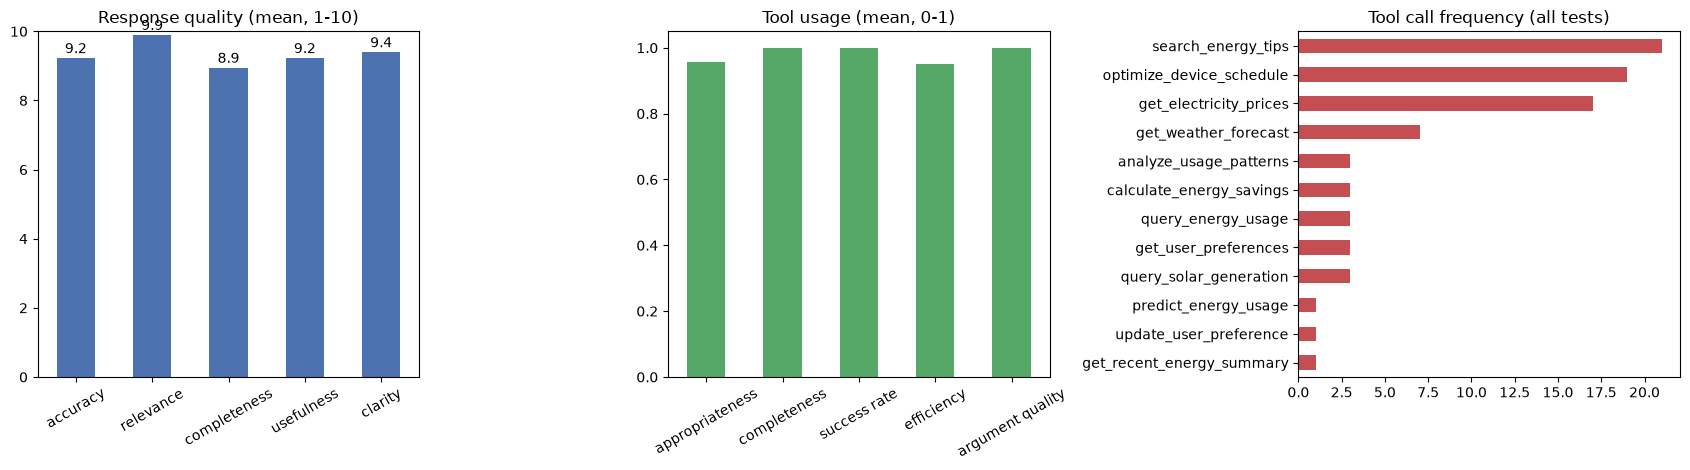

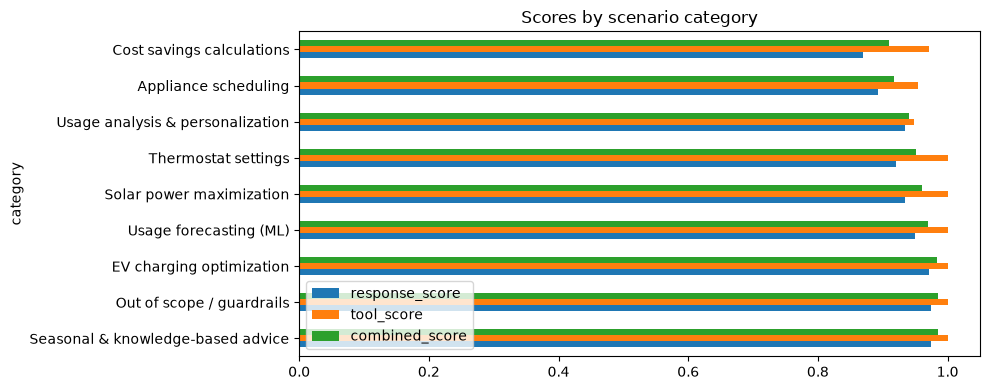

,required,successful_calls,failed_calls,tests
tool,,,,
search_energy_tips,True,21,0,"[ev_charging_1, ev_charging_deadline, thermostat_price_spike, thermostat_heat_precool, dishwasher_offpeak, laundry_w..."
get_electricity_prices,True,17,0,"[ev_charging_1, ev_charging_deadline, thermostat_price_spike, thermostat_heat_precool, dishwasher_offpeak, laundry_w..."
get_weather_forecast,True,7,0,"[ev_charging_1, ev_charging_deadline, thermostat_price_spike, thermostat_heat_precool, laundry_weekend, pool_pump_we..."
calculate_energy_savings,True,3,0,"[dishwasher_offpeak, ev_shift_annual_savings, battery_roi]"
query_energy_usage,True,3,0,"[ev_shift_annual_savings, battery_roi, yesterday_summary]"
query_solar_generation,True,3,0,"[battery_roi, yesterday_summary, solar_week_history]"
get_recent_energy_summary,True,1,0,[recent_24h_summary]
optimize_device_schedule,False,19,0,"[ev_charging_1, ev_charging_deadline, thermostat_price_spike, thermostat_heat_precool, laundry_weekend, pool_pump_we..."
analyze_usage_patterns,False,3,0,"[dishwasher_offpeak, solar_self_consumption, usage_history_three_ways]"


In [23]:
evaluation_report = generate_evaluation_report()
display_evaluation_report(evaluation_report)

## 6. Stand-out Features

### 6a. User personalisation: preferences learned mid-conversation, remembered across turns
The agent saves stated preferences (`update_user_preference`) to the database and the checkpointer keeps the
conversation, so a follow-up question on the same `thread_id` builds on the first.

In [24]:
thread = "demo-personalisation"
turn1 = ecohome_agent.invoke("For future reference: I'm fine with the house up to 80°F while we're out, and my "
                             "priority is cutting carbon more than cost.", context=CONTEXT, thread_id=thread)
print("Turn 1 tools:", [t["tool"] for t in turn1["tool_log"]])
display(Markdown(turn1["final_answer"]))
turn2 = ecohome_agent.invoke("Given that, how should I run the AC and the pool pump tomorrow?", context=CONTEXT,
                             thread_id=thread)
print("Turn 2 tools:", [t["tool"] for t in turn2["tool_log"]])
display(Markdown(turn2["final_answer"]))
print("Stored preferences now include:",
      {k: v for k, v in tools.db_manager.get_preferences().items() if k in ("comfort_max_f", "optimization_priority")
       or k not in __import__("energy_model").DEFAULT_HOUSEHOLD_PROFILE})

Turn 1 tools: ['update_user_preference', 'update_user_preference', 'search_energy_tips']


**Recommendation**: To reduce carbon emissions, allow your heat pump HVAC system to pre-cool your home to about 72-74°F during midday solar hours (10:00-15:00) when solar power is abundant, then let the temperature rise up to your new comfort max of 80°F while you are out during the peak price and demand period (16:00-21:00). This uses clean solar energy to reduce cooling load during high-carbon grid hours.

**Why**: Heating and cooling are the largest energy consumers in your home, often 40-50% of total use, so optimizing HVAC timing has the biggest carbon impact. Your 7.2 kW solar system produces most power midday, which is the cleanest and cheapest energy. By pre-cooling during solar hours, you reduce the need for cooling during the evening peak when grid carbon intensity and prices are highest. Your updated comfort max of 80°F while out allows a wider setback, increasing carbon savings.

**Plan**:
- Pre-cool your home to 72-74°F between 10:00 and 15:00 using solar power.
- Set thermostat setback to allow temperature to rise up to 80°F from 16:00 to 21:00 (peak hours).
- Return to your normal cooling setpoint of 76°F after 21:00.
- Use ceiling fans and close blinds during peak hours to maintain comfort and reduce cooling load.

**Savings**: This strategy can reduce HVAC carbon emissions significantly by shifting cooling load to solar hours and avoiding high-carbon grid power in the evening. Typical savings are around 8-10% of HVAC energy use annually, translating to meaningful CO2 reductions given your heat pump size and solar capacity.

**Tips**:
- HVAC Optimization Strategies (tip_hvac_optimization.txt)
- Smart Home Automation for Energy Savings (tip_smart_home_automation.txt)
- Thermostat setpoints that balance comfort and cost (tip_hvac_optimization.txt)

**Assumptions**: Your heat pump is a 3-ton system, and your solar production peaks midday as typical for San Francisco.

This approach aligns with your carbon priority and updated comfort range, leveraging your solar system to cut emissions without sacrificing comfort. Let me know if you want me to help set this schedule or optimize other devices!

Turn 2 tools: ['get_electricity_prices', 'get_weather_forecast', 'optimize_device_schedule', 'optimize_device_schedule', 'search_energy_tips']


**Recommendation**:  
- Run your AC pre-cooling tomorrow from 10:00 to 15:00 to use abundant solar power and reduce carbon emissions.  
- Run your pool pump from 09:00 to 12:00 to maximize solar self-consumption and avoid higher mid-peak rates later in the day.

**Why**:  
Tomorrow is a sunny day in San Francisco with strong solar production between 10:00 and 15:00, perfect for running your heat pump AC and pool pump on clean solar energy. Electricity prices are lowest during off-peak and solar-midday periods, with mid-peak rates higher from 07:00 to 21:00. Running these devices during solar hours minimizes grid carbon intensity and cost.  

**Plan**:  
- AC pre-cool: 10:00–15:00 (5 hours, ~15 kWh) using mostly solar energy.  
- Pool pump: 09:00–12:00 (3 hours, ~2.5 kWh) fully powered by solar.  

**Savings**:  
- AC pre-cooling saves about $3.60 per run compared to typical afternoon use, with an estimated annual saving of $324 and 3.3 kg CO2 avoided per run.  
- Pool pump run during solar hours costs $0.12, fully solar-powered, avoiding higher mid-peak rates later. No additional savings since typical use is already solar-timed.  

**Tips**:  
- Run pool pumps during solar hours to reduce costs and carbon (tip_pool_spa_energy.txt)  
- HVAC Optimization Strategies emphasize timing HVAC to solar and off-peak hours (tip_hvac_optimization.txt)  
- Maintain pool equipment and consider variable-speed pumps for efficiency (tip_device_best_practices.txt)  

**Assumptions**:  
- AC energy use estimated at 15 kWh for pre-cooling.  
- Pool pump power draw 1.1 kW, run time 3 hours.  

This schedule maximizes your solar self-consumption and carbon savings while avoiding high-carbon grid hours. Let me know if you want help automating these settings!

Stored preferences now include: {'comfort_max_f': 80, 'optimization_priority': 'carbon'}


In [25]:
# Restore the seeded profile so re-runs of the evaluation start from the same state
from sample_data import seed_preferences
from models.energy import UserPreference
with tools.db_manager.get_session() as s:
    s.query(UserPreference).delete(); s.commit()
seed_preferences(tools.db_manager)
print("preferences restored:", len(tools.db_manager.get_preferences()))

preferences restored: 26


### 6b. Visualising a recommendation: tomorrow's prices, solar forecast and the optimal EV window

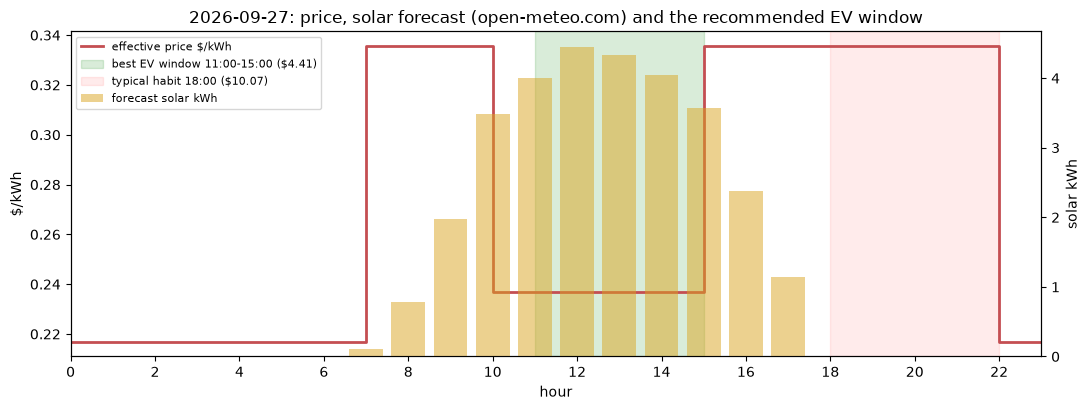

Saving per charge: $5.66 -> about $849.0/year


In [26]:
tomorrow = (datetime.now() + timedelta(days=1)).date().isoformat()
prices = tools.get_electricity_prices.invoke({"date": tomorrow})
wx = tools.get_weather_forecast.invoke({"location": "San Francisco, CA", "days": 2})
plan = tools.optimize_device_schedule.invoke({"device": "ev", "date": tomorrow, "energy_kwh": 30})
solar = [h["estimated_solar_kwh"] for h in wx["hourly"] if h["date"] == tomorrow]
rates = [h["effective_rate"] for h in prices["hourly_rates"]]

fig, ax1 = plt.subplots(figsize=(11, 4.2))
ax1.step(range(24), rates, where="post", color="#c44e52", lw=2, label="effective price $/kWh")
ax1.set(xlabel="hour", ylabel="$/kWh", xticks=range(0, 24, 2), xlim=(0, 23),
        title=f"{tomorrow}: price, solar forecast ({wx['source'].split(' ')[0]}) and the recommended EV window")
ax2 = ax1.twinx()
ax2.bar(range(24), solar, color="goldenrod", alpha=0.5, label="forecast solar kWh")
ax2.set_ylabel("solar kWh")
best = plan["best_window"]
ax1.axvspan(best["start_hour"], best["start_hour"] + plan["duration_hours"], color="green", alpha=0.15,
            label=f"best EV window {best['start']}-{best['end']} (${best['cost_usd']})")
cmp_ = plan["compared_with"]
ax1.axvspan(cmp_["start_hour"], cmp_["start_hour"] + plan["duration_hours"], color="red", alpha=0.08,
            label=f"{cmp_['label']} {cmp_['start']} (${cmp_['cost_usd']})")
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=8)
plt.tight_layout(); plt.savefig(config.REPORTS_DIR / "figures" / "03_ev_window.png", dpi=110); plt.show()
print(f"Saving per charge: ${plan['savings_per_run_usd']} -> about ${plan['estimated_annual_savings_usd']}/year")

### 6c. Savings projection from the household's own history

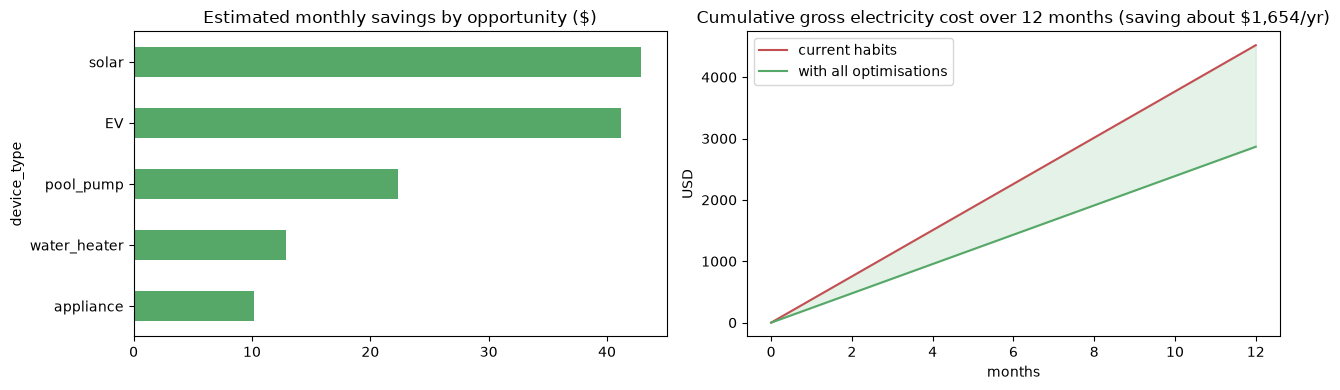

,estimated_monthly_savings_usd,estimated_annual_savings_usd,action
device_type,,,
solar,42.90,521.98,Soak up exported midday solar with flexible loads or a home battery; every exported kWh earns $0.05 but is worth abo...
EV,41.20,494.41,Schedule EV charging to start after 22:00 (or 10:00-15:00 on sunny weekend days) instead of plugging in on arrival.
pool_pump,22.36,268.33,Move the pool pump to 09:00-15:00 so it runs on solar instead of into the 16:00 peak.
water_heater,12.86,154.26,Pre-heat the heat-pump water heater midday and avoid evening recovery in the peak.
appliance,10.19,122.27,"Delay-start the dryer to after 22:00, or run it 10:00-15:00 on solar days."


In [27]:
patterns = tools.analyze_usage_patterns.invoke({"days": 30})
opp = pd.DataFrame(patterns["top_opportunities"]).set_index("device_type")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
opp["estimated_monthly_savings_usd"].sort_values().plot(kind="barh", ax=axes[0], color="#55a868",
                                                        title="Estimated monthly savings by opportunity ($)")
months = list(range(0, 13))
monthly_total = patterns["total_addressable_monthly_savings_usd"]
axes[1].plot(months, [patterns["projected_monthly_bill_usd"] * m for m in months], label="current habits", color="#c44e52")
axes[1].plot(months, [(patterns["projected_monthly_bill_usd"] - monthly_total) * m for m in months],
             label="with all optimisations", color="#55a868")
axes[1].fill_between(months, [(patterns["projected_monthly_bill_usd"] - monthly_total) * m for m in months],
                     [patterns["projected_monthly_bill_usd"] * m for m in months], color="#55a868", alpha=0.15)
axes[1].set(title=f"Cumulative gross electricity cost over 12 months (saving about ${monthly_total * 12:,.0f}/yr)",
            xlabel="months", ylabel="USD"); axes[1].legend()
plt.tight_layout(); plt.savefig(config.REPORTS_DIR / "figures" / "03_savings_projection.png", dpi=110); plt.show()
opp[["estimated_monthly_savings_usd", "estimated_annual_savings_usd", "action"]]

### 6d. Machine-learning forecast of tomorrow's consumption

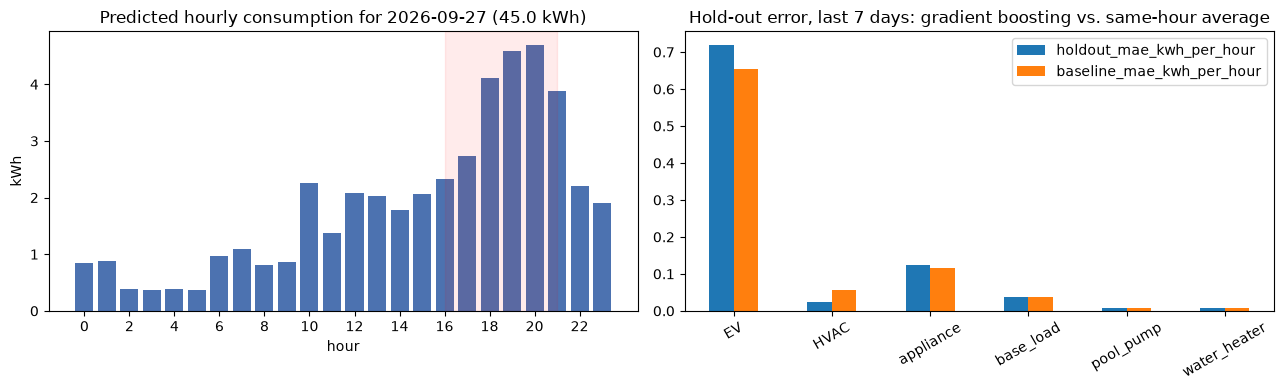

Expected net cost: $7.8 | solar 30.3 kWh | grid import 28.2 kWh


,holdout_mae_kwh_per_hour,baseline_mae_kwh_per_hour
EV,0.720,0.654
HVAC,0.023,0.056
appliance,0.125,0.116
base_load,0.037,0.038
pool_pump,0.008,0.007
water_heater,0.009,0.007


In [28]:
pred = tools.predict_energy_usage.invoke({"target_date": "tomorrow"})
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(24), pred["predicted_hourly_kwh"], color="#4c72b0")
axes[0].axvspan(16, 21, color="red", alpha=0.08)
axes[0].set(title=f"Predicted hourly consumption for {pred['date']} ({pred['predicted_total_kwh']} kWh)",
            xlabel="hour", ylabel="kWh", xticks=range(0, 24, 2))
val = pd.DataFrame(pred["model"]["validation_last_7_days"]).T[["holdout_mae_kwh_per_hour", "baseline_mae_kwh_per_hour"]]
val.plot(kind="bar", ax=axes[1], rot=30, title="Hold-out error, last 7 days: gradient boosting vs. same-hour average")
plt.tight_layout(); plt.savefig(config.REPORTS_DIR / "figures" / "03_ml_forecast.png", dpi=110); plt.show()
print(f"Expected net cost: ${pred['expected_net_cost_usd']} | solar {pred['expected_solar_kwh']} kWh | "
      f"grid import {pred['expected_grid_import_kwh']} kWh")
val

## 7. Conclusions

- The agent answers every scenario category end to end, from the question through context preparation and tool
  calls to a quantified recommendation, and each step is logged in `test_results`.
- Section 5 reports the scores, strengths, weaknesses and prioritised recommendations. The same report is saved as
  `reports/evaluation_report.md` / `.json` with charts in `reports/figures/`.
- Stand-out work: live Open-Meteo weather, hybrid RAG with a retrieval benchmark (notebook 02), a schedule optimiser,
  persistent personalisation with multi-turn memory, ML consumption forecasting, and visualisations.